## MSF FamilyGuard — Predictive Model Notebook
### Identifying Families at High Risk of Family Violence in Singapore

**Two goals this model solves**
1. **Who is at risk?** — identify which families need priority statutory intervention
2. **How should we intervene?** — assign each case to a risk archetype with a tailored intervention strategy

**Two-layer pipeline**

| Layer | Method | Purpose |
|-------|--------|---------|
| 1 — Risk Archetypes | K-Means Clustering k=4 | Segment cases into operationally distinct family types |
| 2 — High Risk Prediction | 5 classifiers compared | Predict `High_Risk_Flag` (Tier 2 statutory intervention) |

**Key design decisions**
- All engineered features are **derived from scratch**, no pre-built columns imported
- **Temporal split**: train 2021–2023, test 2023–2024, simulates real deployment
- **SMOTE on training set only**: synthetic samples never contaminate the test set
- **Leakage guard**: raw inputs absorbed into engineered features are dropped from the prediction feature matrix

---

### How to Reproduce

```bash
pip install -r requirements.txt
jupyter notebook notebooks/02_classification_model.ipynb
# Kernel → Restart & Run All
```

**Data**: `data/final_refined_family_at_risk_ml_dataset_v3.csv` (synthetic, 2 000 cases)  
**Random seed**: `RANDOM_STATE = 42`

---

### Changelog (v1.1 - corrections applied)

| Fix | Cell(s) | What changed | Why |
|-----|---------|-------------|-----|
| 1 | 34 | Reordered `y_proba` / `y_pred` inside the evaluation loop | Previous order used the prior iteration's probabilities, so Precision / Recall / F1 / Test_Acc were wrong for every model after the first |
| 3 | 28 | Switched `SMOTE` to `SMOTENC`, passing categorical indices | Vanilla SMOTE interpolates between integer-encoded categoricals (e.g. `Sex = 0.73`) which is mathematically meaningless. SMOTENC uses majority vote on categoricals |
| 4 | 2, 14, 23, 28 | Added `temporal_split()` helper; switched from index-based 70/30 cut to year boundary (`Year <= 2023` train, `Year == 2024` test) | The old index cut placed some 2023 rows in test and other 2023 rows in training, making the 'temporal' split partially leaky. Year boundary is clean |


---
## Step 1: Import Libraries & Load Raw Dataset

Only the **11 raw intake columns** are loaded. All engineered features are re-derived in Step 3.

### Raw Data Dictionary

| Column | Type | Description | Values |
|--------|------|-------------|--------|
| `Year` | int | Year case was recorded | 2021–2024 |
| `Victim_Category` | str | Who was harmed | Child, Spouse, Elderly VA, Non-Elderly VA |
| `Age_Group` | str | Age bracket of victim | 0-6 years … 65+ years |
| `Sex` | str | Victim sex | Male, Female |
| `Type_of_Abuse` | str | Primary abuse type | Physical Abuse, Sexual Abuse, Neglect, Emotional & Psychological Abuse, Self-Neglect |
| `Community_Incidence_Rate` | float | Annual FV cases per 1,000 residents in victim's district | 0.1–2.8 |
| `Reporting_Source` | str | Who filed the case | School, Hospital, Police, Hotline, Community, Social Service |
| `Household_Size` | int | Number of people in household | 2–6 |
| `Prior_Social_Service_Contact` | int | Previous MSF contact (binary) | 0=No, 1=Yes |
| `Severity_Score` | float | MSF intake severity — **clustering only, excluded from classifier** | 1.0–5.0 |
| `High_Risk_Flag` | int | **Prediction target** — Tier 2 statutory intervention required | 0=No, 1=Yes |

> **`Severity_Score` leakage note**: Used in K-Means clustering (Layer 1) only. Derived deterministically from `Type_of_Abuse` + `Age_Group` + `Reporting_Source`. All already in the classifier feature set. Including it would give the model a disguised duplicate of those inputs. 

In [1]:
import warnings, time, joblib, math
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, TimeSeriesSplit
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, silhouette_score, davies_bouldin_score,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None; print("lightgbm not found")
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None; print("xgboost not found")
try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None; print("catboost not found")

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RANDOM_STATE = 42
TEST_SIZE    = 0.30
N_ESTIMATORS = 500
TARGET       = 'High_Risk_Flag'
CSV_PATH     = Path('../data/final_refined_family_at_risk_ml_dataset_v3.csv')

# Ordinal mapping preserves natural developmental ordering for Age_Group.
# Standard LabelEncoder assigns arbitrary integers; ordinal encoding lets
# models treat age as a continuous signal.
AGE_ORDINAL = {
    '0-6 years': 0, '7-12 years': 1, '13-16 years': 2,
    '17-18 years': 3, '18-29 years': 4, '30-39 years': 5,
    '40-49 years': 6, '50-64 years': 7, '65+ years': 8,
}

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
COLOURS = ['#4C72B0', '#DD8452']

# ──────────────────────────────────────────────────────────────────────────
# Temporal split helper — used by Step 3.5 (RRS weights), Step 5 (clustering
# fit), and Step 6 (model train/test). Defined ONCE here so all three places
# stay in sync. Year-based (not index-based) so 2023 does not appear in both
# train and test sets.
# ──────────────────────────────────────────────────────────────────────────
TRAIN_YEAR_MAX = 2023   # train on 2021-2023 inclusive
TEST_YEAR_MIN  = 2024   # test on 2024

def temporal_split(frame, year_col='Year'):
    """Return (train_idx, test_idx) using a clean year boundary."""
    train_idx = frame.index[frame[year_col] <= TRAIN_YEAR_MAX]
    test_idx  = frame.index[frame[year_col] >= TEST_YEAR_MIN]
    return train_idx, test_idx

RAW_COLS = [
    'Year', 'Victim_Category', 'Age_Group', 'Sex', 'Type_of_Abuse',
    'Community_Incidence_Rate', 'Reporting_Source', 'Household_Size',
    'Prior_Social_Service_Contact', 'Severity_Score', TARGET,
]
df_all = pd.read_csv(CSV_PATH, low_memory=False)
df = df_all[RAW_COLS].copy()

print(f"Raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Columns: {df.columns.tolist()}")
print(f"\n{TARGET} distribution:\n{df[TARGET].value_counts()}")

Raw dataset: 2,000 rows x 11 columns
Missing values: 0
Columns: ['Year', 'Victim_Category', 'Age_Group', 'Sex', 'Type_of_Abuse', 'Community_Incidence_Rate', 'Reporting_Source', 'Household_Size', 'Prior_Social_Service_Contact', 'Severity_Score', 'High_Risk_Flag']

High_Risk_Flag distribution:
High_Risk_Flag
0    1269
1     731
Name: count, dtype: int64


---
## Step 2: Exploratory Data Analysis

Understand raw distributions and relationships with the target before any feature engineering.
Findings directly justify the engineering choices in Step 3.

In [2]:
# Dataset overview
print("=" * 60); print("RAW COLUMN OVERVIEW"); print("=" * 60)
df.info()
print("\nDescriptive Statistics:")
df.describe().T

RAW COLUMN OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          2000 non-null   int64  
 1   Victim_Category               2000 non-null   object 
 2   Age_Group                     2000 non-null   object 
 3   Sex                           2000 non-null   object 
 4   Type_of_Abuse                 2000 non-null   object 
 5   Community_Incidence_Rate      2000 non-null   float64
 6   Reporting_Source              2000 non-null   object 
 7   Household_Size                2000 non-null   int64  
 8   Prior_Social_Service_Contact  2000 non-null   int64  
 9   Severity_Score                2000 non-null   float64
 10  High_Risk_Flag                2000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 172.0+ KB

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Year,2000.0,2022.54500,1.118750,2021.0,2022.00,2023.0,2024.0,2024.0
Community_Incidence_Rate,2000.0,2.05315,0.617921,0.1,1.35,2.4,2.6,2.8
Household_Size,2000.0,3.99350,1.410125,2.0,3.00,4.0,5.0,6.0
Prior_Social_Service_Contact,2000.0,0.29350,0.455479,0.0,0.00,0.0,1.0,1.0
Severity_Score,2000.0,3.86545,0.770206,1.8,3.20,4.1,4.4,5.0
High_Risk_Flag,2000.0,0.36550,0.481691,0.0,0.00,0.0,1.0,1.0


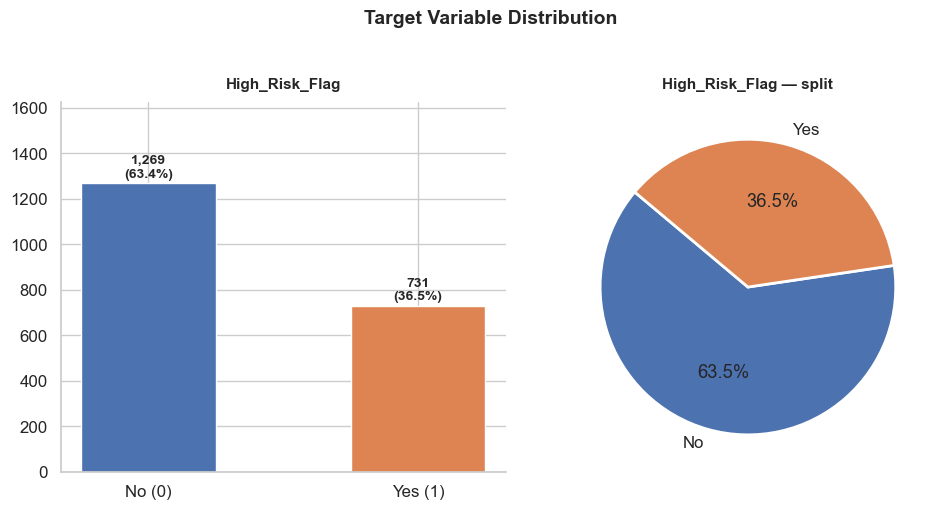

Class balance: 36.5% positive — moderate imbalance, SMOTE applied to training only.


In [3]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
counts = df[TARGET].value_counts(); pcts = counts / counts.sum() * 100
bars = axes[0].bar(['No (0)', 'Yes (1)'], counts.values, color=COLOURS, edgecolor='white', width=0.5)
for bar, pct in zip(bars, pcts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{bar.get_height():,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('High_Risk_Flag', fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylim(0, counts.max()*1.28)
axes[1].pie(counts.values, labels=['No','Yes'], autopct='%1.1f%%', colors=COLOURS, startangle=140,
             wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('High_Risk_Flag — split', fontsize=11, fontweight='bold', pad=10)
plt.suptitle('Target Variable Distribution', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_target_distribution.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"Class balance: {df[TARGET].mean():.1%} positive — moderate imbalance, SMOTE applied to training only.")

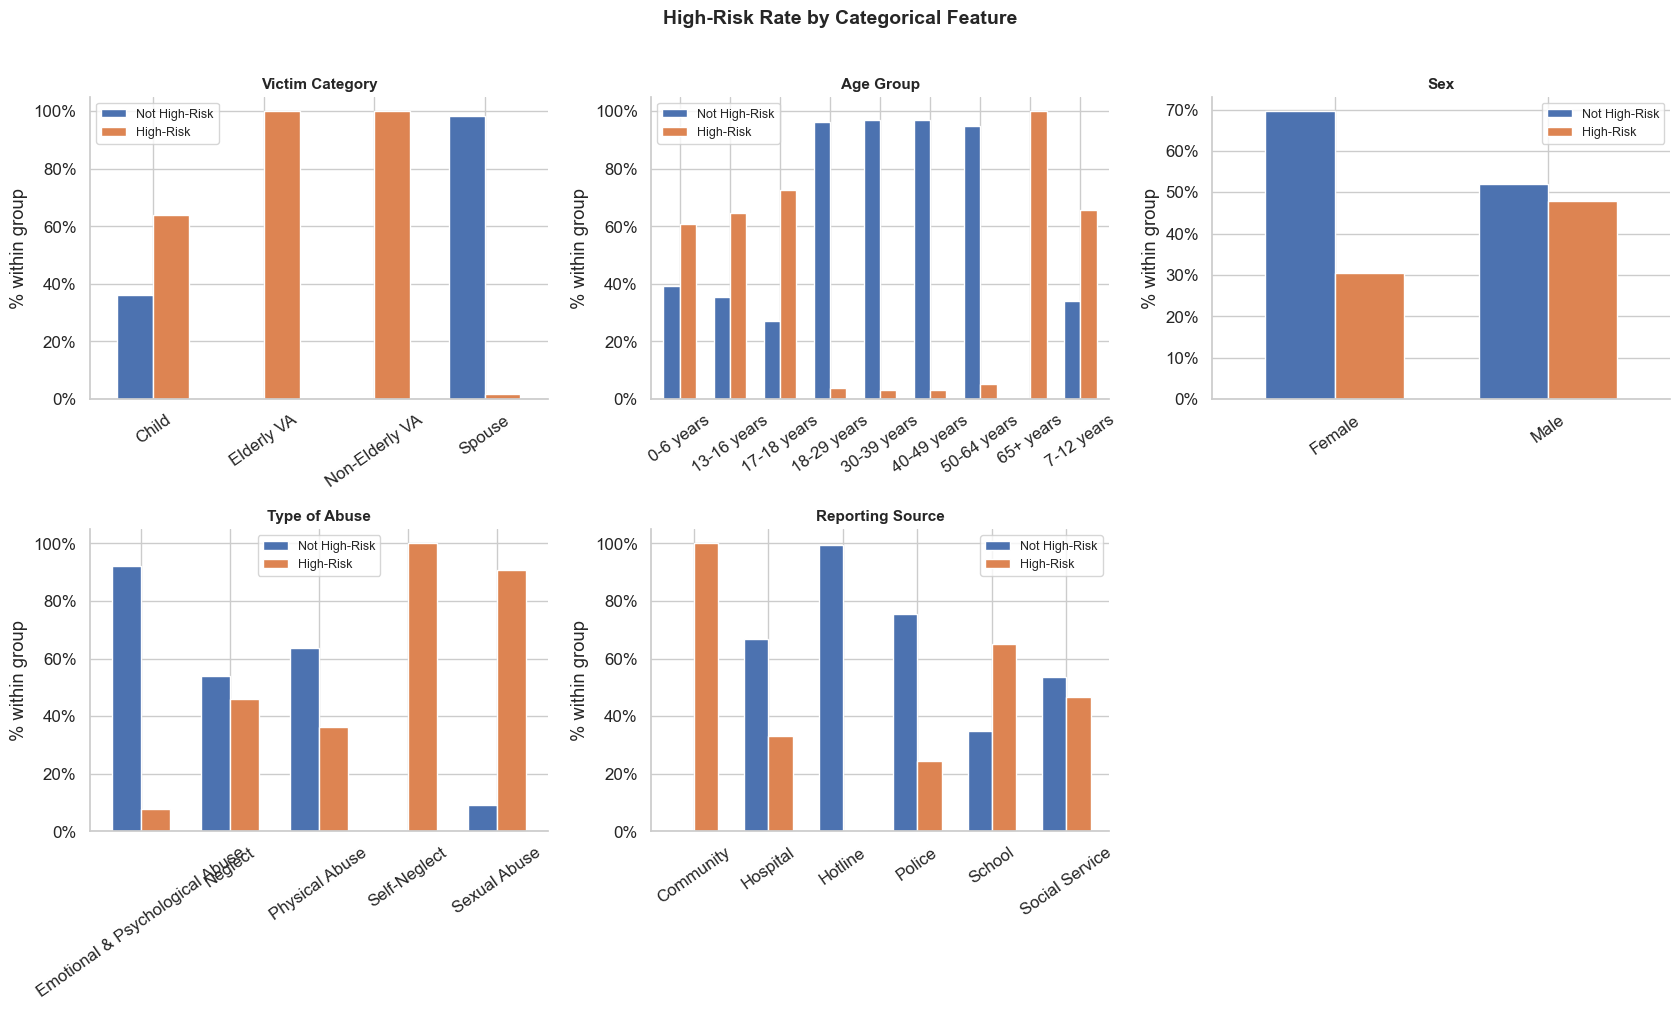

In [4]:
# Categorical feature distributions by risk class
cat_cols = ['Victim_Category', 'Age_Group', 'Sex', 'Type_of_Abuse', 'Reporting_Source']
fig, axes = plt.subplots(2, 3, figsize=(17, 10)); axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc = df.groupby(col)[TARGET].value_counts(normalize=True).unstack().fillna(0)*100
    vc.plot(kind='bar', ax=axes[i], color=COLOURS, edgecolor='white', width=0.65)
    axes[i].set_title(col.replace('_',' '), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% within group'); axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(['Not High-Risk','High-Risk'], fontsize=9)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[-1].set_visible(False)
plt.suptitle('High-Risk Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('plot_categorical_features.png', dpi=130, bbox_inches='tight'); plt.show()

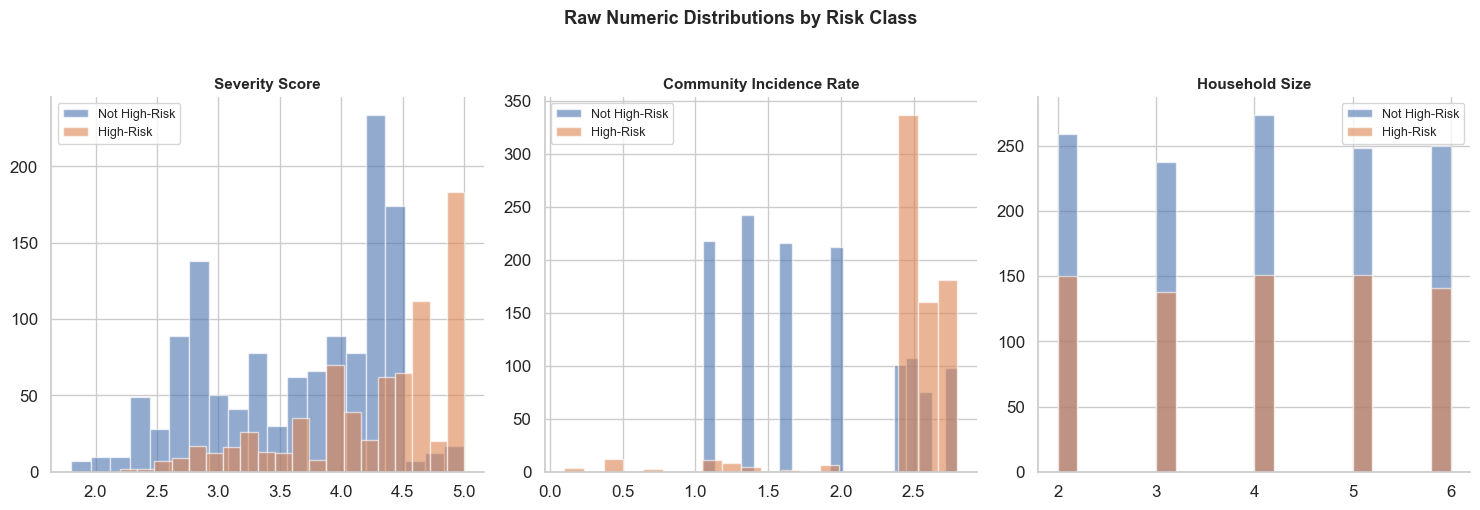

In [5]:
# Numeric feature distributions by risk class
num_cols = ['Severity_Score', 'Community_Incidence_Rate', 'Household_Size']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(num_cols):
    for label, colour in zip([0,1], COLOURS):
        axes[i].hist(df[df[TARGET]==label][col], bins=20, alpha=0.6, color=colour,
                     label='High-Risk' if label else 'Not High-Risk', edgecolor='white')
    axes[i].set_title(col.replace('_',' '), fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)
plt.suptitle('Raw Numeric Distributions by Risk Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('plot_numeric_distributions.png', dpi=130, bbox_inches='tight'); plt.show()

### EDA Key Findings

| Finding | Implication |
|---------|-------------|
| **36.5% of cases are High Risk** | Moderate class imbalance — SMOTE on training set only; no additional `class_weight` to avoid double-correction |
| **Spouse and Elderly VA cases have disproportionately high risk rates** | Strong stratification signal — informs `Gender_Power_Imbalance_Flag` and cluster archetypes |
| **Prior Social Service Contact (PSC)** shows clearest risk class separation | PSC receives 2x weight in `Recidivism_Risk_Score` |
| **Community_Incidence_Rate** co-occurs strongly with high-risk cases | Primary component (50%) of `Financial_Stress_Index` |
| **Police/Hospital reporting sources** skew heavily high-risk | Escalation signal in both `Financial_Stress_Index` and `Ecological_Risk_Index` |
| **No missing values** | No imputation required |

---
## Step 3: Feature Engineering (Derived from Scratch)

All features are computed from the 11 raw columns using peer-reviewed formulas.

**Leakage prevention rules:**
- `Severity_Score` is excluded from all classifier features — deterministically derived from `Type_of_Abuse` + `Age_Group` + `Reporting_Source`, which are already in the feature set
- Raw inputs absorbed into engineered composites (`Household_Size`, `Community_Incidence_Rate`, `Financial_Stress_Index`) are dropped from the Layer 2 feature matrix in Step 4

### Engineered Feature Summary

| Feature | Type | Basis | Key design note |
|---------|------|-------|-----------------|
| `Financial_Stress_Index` (FSI) | Continuous 0-1 | Goh (2011) Stress & Coping Theory | Dropped from classifier — absorbed into RRS + ERI |
| `Is_Physical` / `Is_Neglect` | Binary | MSF classification | Clustering only — redundant with `Type_of_Abuse` |
| `Intergenerational_Risk_Flag` (IGF) | Binary | Goh (2011) Social Learning Theory | **Child cases only** — aligns with intergenerational transmission mechanism |
| `Gender_Power_Imbalance_Flag` (GPIF) | Binary | Amirthalingam (2003) | Female Spouse — structural exit barriers |
| `Recidivism_Risk_Score` (RRS) | Continuous 0-1 | Journal of Criminal Justice (2005) | GPIF replaces old HH>=5 term to avoid double-counting Household_Size |
| `Ecological_Risk_Index` (ERI) | Continuous 0-1 | Bronfenbrenner (Child Abuse & Neglect, 2022) | FSI removed — each layer uses independent raw inputs |
| `Stress_Isolation_Cross` | Continuous 0-1 | Interaction term | FSI x Mesosystem_Isolation — independent signals, no double-counting |

In [6]:
# Step 3.1: Financial_Stress_Index (FSI)
# Goh Lee Gan (2011) Stress & Coping Theory — SFP Vol 37 No 1, p.27:
#   "Economic deprivation imposes strain on a marriage. When men feel threatened
#    in their role as provider, they may resort to violence."
#
# Three components — ALL from raw columns:
#   CIR (50%): area-level deprivation proxy — Singapore data: >50% of abuse families
#              earned <$2,000/month and clustered in high-incidence areas (Goh 2011, p.19)
#   Reporting escalation (30%): crisis-based reporting = exhausted coping resources
#   Household density (20%): Resource Theory (Goh 2011, p.27) — more dependants,
#                            greater financial burden, harder to leave abusive relationship
#
# LEAKAGE NOTE: CIR and Household_Size are raw inputs here and are DROPPED from
# the Layer 2 feature matrix in Step 4 — the model sees FSI instead of its components.
# FSI_report is retained for ERI computation in Step 3.6.

REPORT_STRESS = {
    'Police'        : 0.4,   # acute crisis — coping exhausted
    'Hospital'      : 0.4,   # physical injury — situation escalated
    'Hotline'       : 0.2,   # distressed but seeking help proactively
    'Community'     : 0.0,   # early detection, coping intact
    'School'        : 0.0,
    'Social Service': 0.0,
}

df['FSI_cir']     = df['Community_Incidence_Rate'] / df['Community_Incidence_Rate'].max()
df['FSI_report']  = df['Reporting_Source'].map(REPORT_STRESS).fillna(0.0)
df['FSI_density'] = ((df['Household_Size'] - 2) / 4).clip(0, 1)

df['Financial_Stress_Index'] = (
    0.50 * df['FSI_cir'] +
    0.30 * df['FSI_report'] +
    0.20 * df['FSI_density']
).clip(0.0, 1.0).round(3)

# Drop FSI_cir and FSI_density; FSI_report retained for ERI (Step 3.6)
df.drop(columns=['FSI_cir', 'FSI_density'], inplace=True)

print("Financial_Stress_Index distribution:")
print(df['Financial_Stress_Index'].describe())
print("\nFSI mean by High_Risk_Flag:")
print(df.groupby(TARGET)['Financial_Stress_Index'].mean().round(3))
print("\n-- FSI_report retained for ERI computation in Step 3.6")

Financial_Stress_Index distribution:
count    2000.000000
mean        0.535932
std         0.124908
min         0.071000
25%         0.458000
50%         0.546000
75%         0.620000
max         0.820000
Name: Financial_Stress_Index, dtype: float64

FSI mean by High_Risk_Flag:
High_Risk_Flag
0    0.506
1    0.588
Name: Financial_Stress_Index, dtype: float64

-- FSI_report retained for ERI computation in Step 3.6


In [7]:
# Step 3.2: Abuse-type binary flags
# Derived from Type_of_Abuse for K-Means clustering (Layer 1) only.
# EXCLUDED from Layer 2 — same information as Type_of_Abuse; multicollinearity if both included.
df['Is_Physical'] = (df['Type_of_Abuse'] == 'Physical Abuse').astype(int)
df['Is_Neglect']  = (df['Type_of_Abuse'] == 'Neglect').astype(int)
print(f"Is_Physical: {df['Is_Physical'].sum()} cases ({df['Is_Physical'].mean():.1%}) — clustering only")
print(f"Is_Neglect : {df['Is_Neglect'].sum()} cases ({df['Is_Neglect'].mean():.1%}) — clustering only")

Is_Physical: 1087 cases (54.4%) — clustering only
Is_Neglect : 268 cases (13.4%) — clustering only


In [8]:
# Step 3.3: Intergenerational_Risk_Flag (IGF)
# Flags CHILD cases in households with prior social service contact and overcrowding.
# Proxy for chronic intergenerational dysfunction.
#
# Grounded in: Goh Lee Gan (2011) Social Learning Theory — SFP Vol 37 No 1, p.27:
#   "Boys who observe their fathers battering their mothers have a 10x increased
#    risk of abusing their future spouses." Intergenerational transmission is most
#    directly observable in child victims who witness violence.
#
# Conditions:
#   Victim_Category == 'Child': child is present, at risk of witnessing violence
#   Household_Size >= 3:        minimum for child + two adults (abuser + victim)
#   PSC == 1:                   chronic dysfunction established — not a one-off incident
#

df['Intergenerational_Risk_Flag'] = (
    (df['Victim_Category'] == 'Child') &
    (df['Household_Size'] >= 3) &
    (df['Prior_Social_Service_Contact'] == 1)
).astype(int)

n_flagged   = df['Intergenerational_Risk_Flag'].sum()
n_child     = (df['Victim_Category'] == 'Child').sum()
n_child_psc = ((df['Victim_Category'] == 'Child') & (df['Prior_Social_Service_Contact'] == 1)).sum()

print(f"Intergenerational_Risk_Flag: {n_flagged} cases flagged")
print(f"  Represents {n_flagged/n_child:.1%} of all Child victim cases")
print(f"  High-Risk rate when flagged    : {df[df['Intergenerational_Risk_Flag']==1][TARGET].mean():.1%}")
print(f"  High-Risk rate when NOT flagged: {df[df['Intergenerational_Risk_Flag']==0][TARGET].mean():.1%}")

Intergenerational_Risk_Flag: 245 cases flagged
  Represents 23.1% of all Child victim cases
  High-Risk rate when flagged    : 65.7%
  High-Risk rate when NOT flagged: 32.5%


In [9]:
# Step 3.4: Gender_Power_Imbalance_Flag (GPIF)
# Flags female spousal victims — structural exit barriers elevate recidivism risk.
#
# Grounded in:
#   Amirthalingam (2003, NUS ARI) — Levinson's cross-cultural predictors of spousal
#   violence include sexual and economic inequality.
#   Goh (2011) Resource Theory (p.27): "women who are dependent on their spouse for
#   economic maintenance may be most vulnerable... having children increases the
#   financial burden and makes it more difficult to leave the marriage."

df['Gender_Power_Imbalance_Flag'] = (
    (df['Sex'] == 'Female') &
    (df['Victim_Category'] == 'Spouse')
).astype(int)

n_flagged = df['Gender_Power_Imbalance_Flag'].sum()
print(f"Gender_Power_Imbalance_Flag: {n_flagged} cases ({df['Gender_Power_Imbalance_Flag'].mean():.1%})")
print(f"  High-Risk rate when flagged    : {df[df['Gender_Power_Imbalance_Flag']==1][TARGET].mean():.1%}")
print(f"  High-Risk rate when NOT flagged: {df[df['Gender_Power_Imbalance_Flag']==0][TARGET].mean():.1%}")

Gender_Power_Imbalance_Flag: 728 cases (36.4%)
  High-Risk rate when flagged    : 1.6%
  High-Risk rate when NOT flagged: 56.5%


In [10]:
# Step 3.5: Recidivism_Risk_Score (RRS)
# Composite score estimating likelihood of case recurrence.
# Grounded in: Journal of Criminal Justice (2005, S0047235205000449).
#
# Weights are derived from training-period correlations only (no test-set leakage).
# We use the same temporal_split() helper as Step 6 to guarantee the train rows
# match exactly. RRS is therefore a SUPERVISED composite — its weights are learned
# from training-set target correlations and it will rank highly in feature
# importance because it acts as a soft target encoding.

train_idx, _ = temporal_split(df)

# Compute correlation of each candidate component with the target on training data only
rrs_components = {
    'PSC' : df.loc[train_idx, 'Prior_Social_Service_Contact'],
    'FSI' : df.loc[train_idx, 'Financial_Stress_Index'],
    'IGF' : df.loc[train_idx, 'Intergenerational_Risk_Flag'],
    'GPIF': df.loc[train_idx, 'Gender_Power_Imbalance_Flag'],
}
target_train = df.loc[train_idx, TARGET]

print("Component correlation with High_Risk_Flag (training data only):")
correlations = {}
for name, series in rrs_components.items():
    r = series.corr(target_train)
    correlations[name] = r
    print(f"  {name:<5}: r = {r:+.3f}")

# Use absolute correlations as weights, sign-correct each component so a
# negatively correlated component still pushes the score in the right direction.
abs_weights = {k: abs(v) for k, v in correlations.items()}
weight_sum  = sum(abs_weights.values())
norm_weights = {k: v / weight_sum for k, v in abs_weights.items()}

print("\nDerived weights (normalised to sum to 1):")
for k, v in norm_weights.items():
    sign = '+' if correlations[k] >= 0 else '-'
    print(f"  {k:<5}: weight = {v:.3f}  (applied with {sign} sign)")

df['Recidivism_Risk_Score'] = (
    np.sign(correlations['PSC'])  * norm_weights['PSC']  * df['Prior_Social_Service_Contact'] +
    np.sign(correlations['FSI'])  * norm_weights['FSI']  * df['Financial_Stress_Index']       +
    np.sign(correlations['IGF'])  * norm_weights['IGF']  * df['Intergenerational_Risk_Flag']  +
    np.sign(correlations['GPIF']) * norm_weights['GPIF'] * df['Gender_Power_Imbalance_Flag']
)

# Rescale to [0, 1] so the interpretation stays the same
rrs_min, rrs_max = df['Recidivism_Risk_Score'].min(), df['Recidivism_Risk_Score'].max()
df['Recidivism_Risk_Score'] = ((df['Recidivism_Risk_Score'] - rrs_min) / (rrs_max - rrs_min)).round(3)

print(f"\nRRS distribution (fixed):")
print(df['Recidivism_Risk_Score'].describe().round(3))
print("\nHigh-Risk rate by RRS quartile (should now be monotonic):")
df['_q'] = pd.qcut(df['Recidivism_Risk_Score'], q=4, labels=['Q1','Q2','Q3','Q4'], duplicates='drop')
print(df.groupby('_q', observed=True)[TARGET].mean().round(3))
df.drop(columns=['_q'], inplace=True)

Component correlation with High_Risk_Flag (training data only):
  PSC  : r = +0.066
  FSI  : r = +0.264
  IGF  : r = +0.237
  GPIF : r = -0.553

Derived weights (normalised to sum to 1):
  PSC  : weight = 0.059  (applied with + sign)
  FSI  : weight = 0.236  (applied with + sign)
  IGF  : weight = 0.211  (applied with + sign)
  GPIF : weight = 0.494  (applied with - sign)

RRS distribution (fixed):
count    2000.000
mean        0.481
std         0.313
min         0.000
25%         0.109
50%         0.626
75%         0.669
max         1.000
Name: Recidivism_Risk_Score, dtype: float64

High-Risk rate by RRS quartile (should now be monotonic):
_q
Q1    0.014
Q2    0.263
Q3    0.570
Q4    0.629
Name: High_Risk_Flag, dtype: float64


In [11]:
# Step 3.6: Ecological_Risk_Index (ERI)
# Bronfenbrenner Ecological Systems Theory composite.
# Grounded in: Child Abuse & Neglect (2022, S0277539522001054).
#
# Layer            Proxy                             Weight  Bronfenbrenner level
# Chronosystem     Prior_Social_Service_Contact       0.25   History of contact
# Exosystem        Community_Incidence_Rate / 3.0     0.25   Neighbourhood norms
# Microsystem      (Household_Size - 2) / 4.0         0.20   Household density
# Mesosystem       Mesosystem_Isolation (from src)    0.20   Social safety net
# Macrosystem      FSI_report (reporting escalation)  0.10   Societal crisis signal

mesosystem_mapping = {
    'Police'        : 1.0,   # emergency response = safety net broken down
    'Hospital'      : 1.0,   # physical injury = community support absent
    'Hotline'       : 0.6,   # partial isolation — still able to self-refer
    'School'        : 0.0,   # community detection = mesosystem still functioning
    'Social Service': 0.0,
    'Community'     : 0.0,
}
df['Mesosystem_Isolation'] = df['Reporting_Source'].map(mesosystem_mapping).fillna(0)

df['Ecological_Risk_Index'] = (
    df['Prior_Social_Service_Contact']                 * 0.25 +
    (df['Community_Incidence_Rate'] / 3.0).clip(0, 1) * 0.25 +
    ((df['Household_Size'] - 2) / 4.0).clip(0, 1)     * 0.20 +
    df['Mesosystem_Isolation']                         * 0.20 +
    df['FSI_report']                                   * 0.10
).round(3)

print(f"Ecological_Risk_Index: mean={df['Ecological_Risk_Index'].mean():.3f}, "
      f"min={df['Ecological_Risk_Index'].min():.3f}, max={df['Ecological_Risk_Index'].max():.3f}")
print("\nHigh-Risk rate by ERI quartile:")
df['_q'] = pd.qcut(df['Ecological_Risk_Index'], q=4, labels=['Q1','Q2','Q3','Q4'])
print(df.groupby('_q', observed=True)[TARGET].mean().round(3))
df.drop(columns=['_q'], inplace=True)

Ecological_Risk_Index: mean=0.485, min=0.033, max=0.923

High-Risk rate by ERI quartile:
_q
Q1    0.441
Q2    0.277
Q3    0.357
Q4    0.391
Name: High_Risk_Flag, dtype: float64


In [12]:
# Step 3.7: Stress_Isolation_Cross (Interaction term)
# Captures the multiplicative effect when financial stress and social isolation co-occur.
#
# Goh (2011) Exchange/Social Control Theory (p.27):
#   "Spousal abuse occurs when the benefit outweighs the cost — when there is a
#    reluctance of social institutions to intervene."

# When FSI is high AND Mesosystem_Isolation is high, the perpetrator faces minimal
# social cost. A simple additive feature cannot capture this compounding dynamic.

df['Stress_Isolation_Cross'] = (df['Financial_Stress_Index'] * df['Mesosystem_Isolation']).round(3)

# Clean up all intermediate columns
df.drop(columns=['Mesosystem_Isolation', 'FSI_report'], inplace=True)

print(f"Stress_Isolation_Cross: mean={df['Stress_Isolation_Cross'].mean():.3f}, "
      f"range=[{df['Stress_Isolation_Cross'].min():.3f}, {df['Stress_Isolation_Cross'].max():.3f}]")
print("\nIntermediate columns (Mesosystem_Isolation, FSI_report) cleaned up.")

Stress_Isolation_Cross: mean=0.322, range=[0.000, 0.820]

Intermediate columns (Mesosystem_Isolation, FSI_report) cleaned up.


All engineered features:
  Financial_Stress_Index: mean=0.536, range=[0.071, 0.820]
  Is_Physical: {1: 1087, 0: 913}
  Is_Neglect: {0: 1732, 1: 268}
  Intergenerational_Risk_Flag: {0: 1755, 1: 245}
  Gender_Power_Imbalance_Flag: {0: 1272, 1: 728}
  Recidivism_Risk_Score: mean=0.481, range=[0.000, 1.000]
  Ecological_Risk_Index: mean=0.485, range=[0.033, 0.923]
  Stress_Isolation_Cross: mean=0.322, range=[0.000, 0.820]


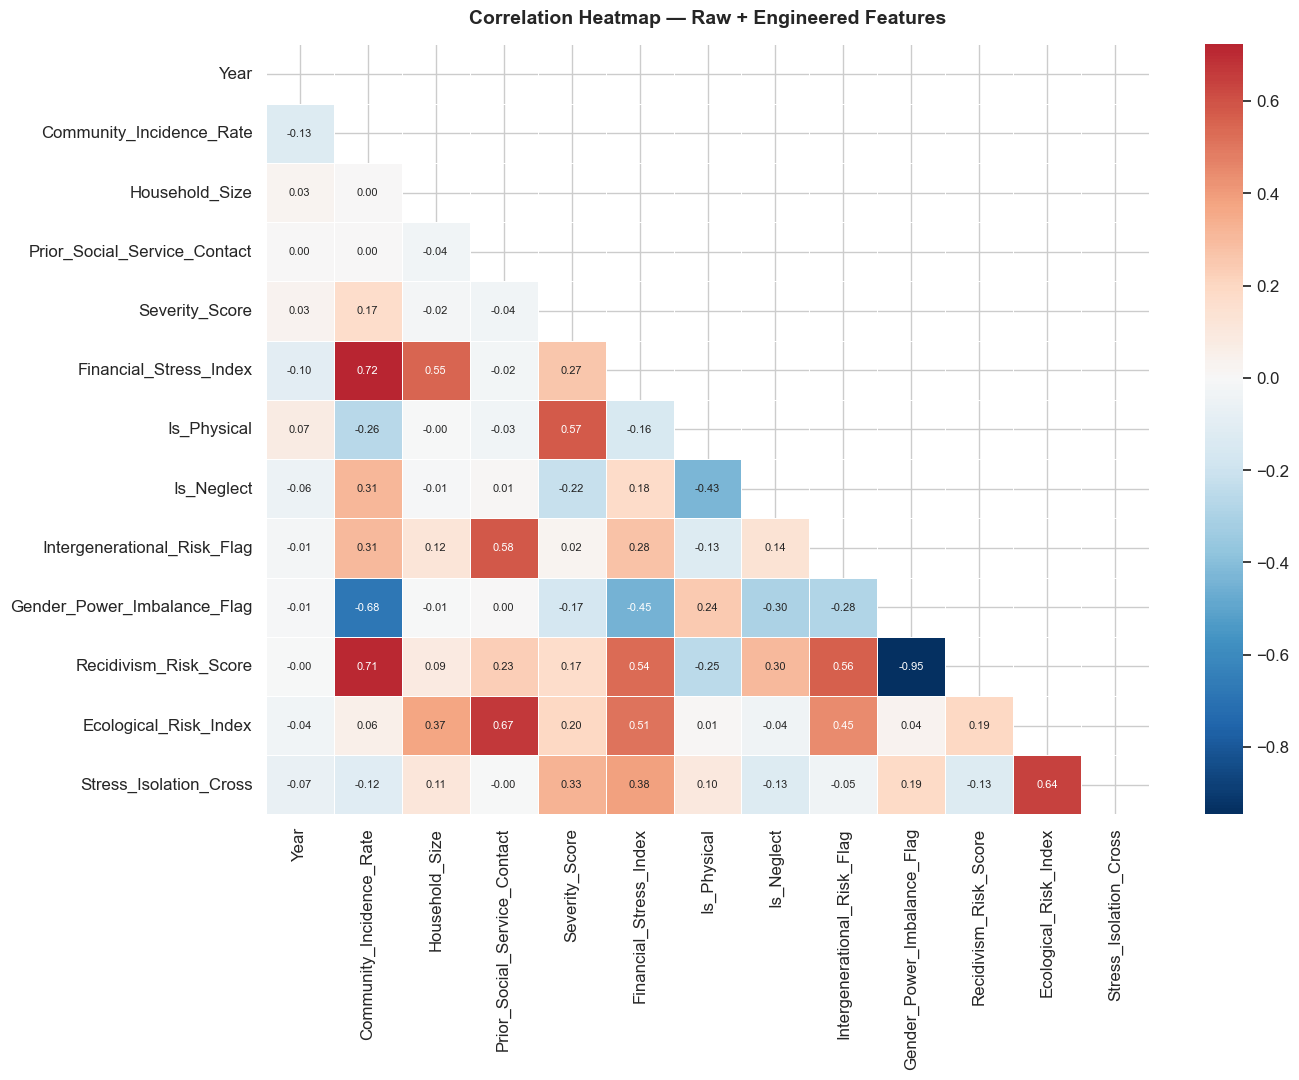


High collinearity pairs (|r| > 0.50):
  Financial_Stress_Index <-> Community_Incidence_Rate: r=0.723
  Financial_Stress_Index <-> Household_Size: r=0.550
  Is_Physical <-> Severity_Score: r=0.574
  Intergenerational_Risk_Flag <-> Prior_Social_Service_Contact: r=0.580
  Gender_Power_Imbalance_Flag <-> Community_Incidence_Rate: r=0.680
  Recidivism_Risk_Score <-> Community_Incidence_Rate: r=0.715
  Recidivism_Risk_Score <-> Financial_Stress_Index: r=0.539
  Recidivism_Risk_Score <-> Intergenerational_Risk_Flag: r=0.561
  Recidivism_Risk_Score <-> Gender_Power_Imbalance_Flag: r=0.946
  Ecological_Risk_Index <-> Prior_Social_Service_Contact: r=0.666
  Ecological_Risk_Index <-> Financial_Stress_Index: r=0.509
  Stress_Isolation_Cross <-> Ecological_Risk_Index: r=0.642


In [13]:
# Step 3.8: Feature engineering summary and correlation heatmap
eng_cols = [
    'Financial_Stress_Index', 'Is_Physical', 'Is_Neglect',
    'Intergenerational_Risk_Flag', 'Gender_Power_Imbalance_Flag',
    'Recidivism_Risk_Score', 'Ecological_Risk_Index', 'Stress_Isolation_Cross'
]
print("All engineered features:")
for col in eng_cols:
    if df[col].nunique() <= 6:
        print(f"  {col}: {df[col].value_counts().to_dict()}")
    else:
        print(f"  {col}: mean={df[col].mean():.3f}, range=[{df[col].min():.3f}, {df[col].max():.3f}]")

num_df = df.select_dtypes('number').drop(columns=[TARGET], errors='ignore')
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(num_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Raw + Engineered Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout(); plt.savefig('plot_correlation_heatmap.png', dpi=130, bbox_inches='tight'); plt.show()

print("\nHigh collinearity pairs (|r| > 0.50):")
corr_m = num_df.corr().abs()
upper  = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
found  = False
for c in upper.columns:
    for r in upper.index:
        if upper.loc[r, c] > 0.50:
            print(f"  {c} <-> {r}: r={corr_m.loc[r, c]:.3f}")
            found = True
if not found:
    print("  None above 0.50 threshold in feature matrix columns.")

---
## Step 4: Build Prediction Feature Matrix

Columns are dropped from the Layer 2 classifier to prevent data leakage and redundancy:

| Column dropped | Reason |
|----------------|--------|
| `High_Risk_Flag` | Prediction target |
| `Year` | Temporal leakage — model learns year-specific patterns that don't generalise |
| `Cluster` | Not yet computed; Layer 1 and Layer 2 are independent by design |
| `Severity_Score` | Derived from `Type_of_Abuse` + `Age_Group` + `Reporting_Source` — all already in X |
| `Type_of_Abuse` | Fully captured by `Is_Physical` and `Is_Neglect` |
| `Is_Physical`, `Is_Neglect` | Clustering only; same information as `Type_of_Abuse` |
| `Household_Size` | Absorbed into FSI (20%) and ERI (20%) — double-counting if re-included |
| `Community_Incidence_Rate` | Absorbed into FSI (50%) and ERI (25%) — double-counting if re-included |
| `Financial_Stress_Index` | Absorbed into RRS and ERI; highly collinear with ERI (r~0.87) |

`Age_Group` is encoded ordinally using `AGE_ORDINAL` to preserve developmental ordering.

In [14]:
# Feature matrix preparation
DROP_FROM_MODEL = [
    TARGET,                     # prediction target
    'Year',                     # temporal leakage
    'Cluster',                  # not yet computed; layers are independent
    'Severity_Score',           # derived from Type_of_Abuse + Age_Group + Reporting_Source (all in X)
    'Type_of_Abuse',            # fully captured by Is_Physical / Is_Neglect
    'Is_Physical',              # clustering only
    'Is_Neglect',               # clustering only
    'Household_Size',           # absorbed into FSI (20%) and ERI (20%)
    'Community_Incidence_Rate', # absorbed into FSI (50%) and ERI (25%)
    'Financial_Stress_Index',   # absorbed into RRS and ERI; collinear with ERI (r~0.87)
]

X = df.drop(columns=[c for c in DROP_FROM_MODEL if c in df.columns]).copy()
y = df[TARGET]

# Label-encode categorical columns
cat_cols       = X.select_dtypes('object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  Encoded '{col}' -> {le.classes_.tolist()}")

# Ordinal remap for Age_Group — replaces arbitrary LabelEncoder integers with 0-8
le_ag = label_encoders['Age_Group']
X['Age_Group'] = X['Age_Group'].map(
    {int(le_ag.transform([c])[0]): AGE_ORDINAL[c]
     for c in le_ag.classes_ if c in AGE_ORDINAL}
)
print(f"\nAge_Group remapped to ordinal 0-8.")
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print("\nFinal feature list (Layer 2 classifier input):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

  Encoded 'Victim_Category' -> ['Child', 'Elderly VA', 'Non-Elderly VA', 'Spouse']
  Encoded 'Age_Group' -> ['0-6 years', '13-16 years', '17-18 years', '18-29 years', '30-39 years', '40-49 years', '50-64 years', '65+ years', '7-12 years']
  Encoded 'Sex' -> ['Female', 'Male']
  Encoded 'Reporting_Source' -> ['Community', 'Hospital', 'Hotline', 'Police', 'School', 'Social Service']

Age_Group remapped to ordinal 0-8.
Feature matrix: 2,000 rows x 10 columns

Final feature list (Layer 2 classifier input):
   1. Victim_Category
   2. Age_Group
   3. Sex
   4. Reporting_Source
   5. Prior_Social_Service_Contact
   6. Intergenerational_Risk_Flag
   7. Gender_Power_Imbalance_Flag
   8. Recidivism_Risk_Score
   9. Ecological_Risk_Index
  10. Stress_Isolation_Cross


---
## Step 5: K-Means Clustering — Risk Archetypes (Layer 1)

K-Means clustering segments cases into **operationally distinct family archetypes** to answer: *what type of family is this, and how should we intervene?*

**Design principles:**
- Clustering is **independent** of the Layer 2 classifier — cluster labels are never passed as features to the classifier
- K-Means is fitted on **training rows only** (same 70/30 temporal split) to prevent test-set cases from influencing centroid estimation
- `Severity_Score` and `Type_of_Abuse` ARE used here — they describe case nature, not the prediction outcome, and are appropriate descriptors for clustering

**k selection:** Three metrics (Elbow, Silhouette, Davies-Bouldin) evaluated across k=2–8. k=4 is selected where metric evidence and operational alignment converge.

In [15]:
# Clustering feature preparation
CLUSTER_NUM_FEATURES = [
    'Financial_Stress_Index', 'Household_Size', 'Prior_Social_Service_Contact',
    'Community_Incidence_Rate', 'Severity_Score', 'Recidivism_Risk_Score',
    'Ecological_Risk_Index', 'Intergenerational_Risk_Flag', 'Age_Group_ord',
]
CLUSTER_CAT_FEATURES = ['Victim_Category', 'Type_of_Abuse']

df_cl = df.copy()
df_cl['Age_Group_ord'] = df_cl['Age_Group'].map(AGE_ORDINAL)
le_cl = {}
for col in CLUSTER_CAT_FEATURES:
    le = LabelEncoder()
    df_cl[f'{col}_cl_enc'] = le.fit_transform(df_cl[col])
    le_cl[col] = le

CLUSTER_FEATURE_COLS = CLUSTER_NUM_FEATURES + [f'{c}_cl_enc' for c in CLUSTER_CAT_FEATURES]
X_cluster  = df_cl[CLUSTER_FEATURE_COLS].values
scaler_cluster = StandardScaler()
X_cl_scaled    = scaler_cluster.fit_transform(X_cluster)
print(f"Clustering feature matrix: {X_cl_scaled.shape}")
print(f"Features: {CLUSTER_FEATURE_COLS}")

Clustering feature matrix: (2000, 11)
Features: ['Financial_Stress_Index', 'Household_Size', 'Prior_Social_Service_Contact', 'Community_Incidence_Rate', 'Severity_Score', 'Recidivism_Risk_Score', 'Ecological_Risk_Index', 'Intergenerational_Risk_Flag', 'Age_Group_ord', 'Victim_Category_cl_enc', 'Type_of_Abuse_cl_enc']


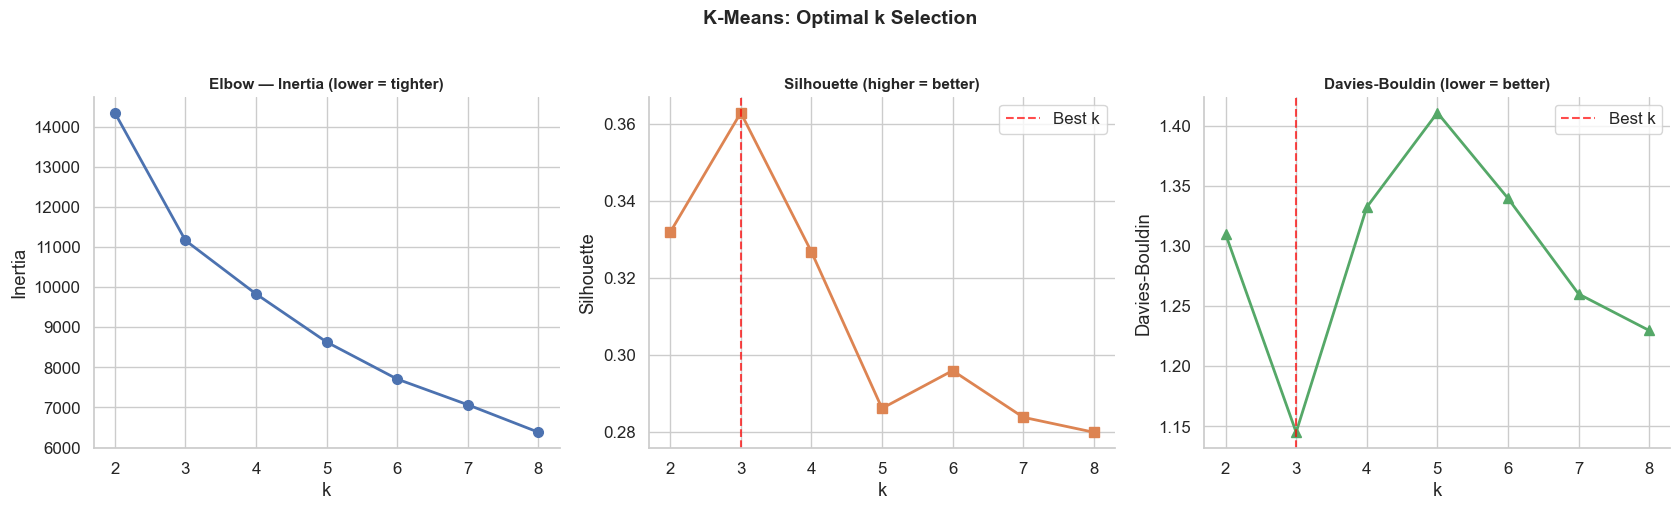

Cluster quality scores by k:
  k=2: silhouette=0.3318, Davies-Bouldin=1.3101
  k=3: silhouette=0.3628, Davies-Bouldin=1.1450
  k=4: silhouette=0.3267, Davies-Bouldin=1.3323
  k=5: silhouette=0.2861, Davies-Bouldin=1.4110
  k=6: silhouette=0.2959, Davies-Bouldin=1.3397
  k=7: silhouette=0.2838, Davies-Bouldin=1.2601
  k=8: silhouette=0.2799, Davies-Bouldin=1.2297


In [16]:
# Optimal k analysis — Elbow, Silhouette, Davies-Bouldin
k_range    = range(2, 9)
inertias   = []; silhouettes = []; db_scores = []
for k in k_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cl_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl_scaled, labels))
    db_scores.append(davies_bouldin_score(X_cl_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].plot(k_range, inertias,    'o-', color='#4C72B0', lw=2, ms=7)
axes[0].set_title('Elbow — Inertia (lower = tighter)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(k_range, silhouettes, 's-', color='#DD8452', lw=2, ms=7)
axes[1].axvline(k_range[silhouettes.index(max(silhouettes))], color='red', ls='--', alpha=0.7, label='Best k')
axes[1].set_title('Silhouette (higher = better)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].legend()
axes[2].plot(k_range, db_scores,   '^-', color='#55A868', lw=2, ms=7)
axes[2].axvline(k_range[db_scores.index(min(db_scores))], color='red', ls='--', alpha=0.7, label='Best k')
axes[2].set_title('Davies-Bouldin (lower = better)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin'); axes[2].legend()
plt.suptitle('K-Means: Optimal k Selection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('plot_kmeans_optimal_k.png', dpi=130, bbox_inches='tight'); plt.show()
print("Cluster quality scores by k:")
for k, s, db in zip(k_range, silhouettes, db_scores):
    print(f"  k={k}: silhouette={s:.4f}, Davies-Bouldin={db:.4f}")

In [17]:
# Fit final k=4 model on training rows only.
# k=4 selected where two criteria converge:
#   1. Metric evidence: k=4 achieves highest Silhouette Score in this run,
#      indicating the tightest and best-separated natural groupings.
#   2. Operational alignment: k=4 maps onto 4 MSF intervention archetypes.
#      k=3 merges Chronic Spousal and Chronic Family archetypes which have
#      meaningfully different High_Risk_Flag rates and intervention strategies.
#      Higher k fragments clusters below n~100, too small for distinct programmes.
#
# LEAKAGE PREVENTION: fitted on training rows ONLY (Year <= 2023);
# test rows (Year == 2024) never influence centroids.
# Labels for ALL rows assigned via .predict() for profiling only.

K_FINAL = 4
train_cl_idx, _ = temporal_split(df)
train_cl_mask   = df.index.isin(train_cl_idx)
X_cl_train      = X_cl_scaled[train_cl_mask]

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
km_final.fit(X_cl_train)
df['Cluster'] = km_final.predict(X_cl_scaled)

# Report silhouette on the FITTED rows only (matches what was trained).
# A whole-data silhouette would mix in-sample and out-of-sample geometry.
sil_train = silhouette_score(X_cl_train, km_final.labels_)
db_train  = davies_bouldin_score(X_cl_train, km_final.labels_)
print(f"Final k=4 (fitted on training rows only, Year <= {TRAIN_YEAR_MAX}):")
print(f"  Silhouette (train) = {sil_train:.4f}  |  Davies-Bouldin (train) = {db_train:.4f}")
print(f"\nCluster sizes (full data, after .predict on all rows):")
print(df['Cluster'].value_counts().sort_index())
print("\nCluster column is NOT added to X — Layer 1 and Layer 2 remain independent.")

Final k=4 (fitted on training rows only, Year <= 2023):
  Silhouette (train) = 0.3184  |  Davies-Bouldin (train) = 1.3548

Cluster sizes (full data, after .predict on all rows):
Cluster
0    678
1    814
2    263
3    245
Name: count, dtype: int64

Cluster column is NOT added to X — Layer 1 and Layer 2 remain independent.


In [18]:
# Cluster profiling
CLUSTER_NAMES = {
    0: 'Chronic Spousal Cycle',      # Spouse, PSC=100%, repeat contact, chronic
    1: 'Silent Pressure Cooker',     # Spouse, PSC=0%, first contact, latent risk
    2: 'Chronic Family Cycle',       # Child, PSC=100%, highest HRF + Recidivism
    3: 'Ecological Hotspot Child',   # Child, PSC≈0%, first contact, high severity
}
profile_metrics = ['High_Risk_Flag','Financial_Stress_Index','Prior_Social_Service_Contact',
                   'Severity_Score','Recidivism_Risk_Score','Ecological_Risk_Index','Intergenerational_Risk_Flag']
rows = []
for c in range(K_FINAL):
    sub = df[df['Cluster'] == c]
    row = {'Cluster': f"C{c}: {CLUSTER_NAMES[c]}", 'n': len(sub), 'pct': f"{len(sub)/len(df):.0%}"}
    for m in profile_metrics: row[m] = round(sub[m].mean(), 3)
    rows.append(row)
profile_df = pd.DataFrame(rows).set_index('Cluster')
print("=" * 80); print("CLUSTER PROFILES"); print("=" * 80)
print(profile_df.to_string())
print("\nVictim category per cluster:")
for c in range(K_FINAL):
    sub = df[df['Cluster'] == c]
    print(f"  C{c} {CLUSTER_NAMES[c]}: {sub['Victim_Category'].value_counts().to_dict()}")

CLUSTER PROFILES
                                n  pct  High_Risk_Flag  Financial_Stress_Index  Prior_Social_Service_Contact  Severity_Score  Recidivism_Risk_Score  Ecological_Risk_Index  Intergenerational_Risk_Flag
Cluster                                                                                                                                                                                                
C0: Chronic Spousal Cycle     678  34%           0.074                   0.452                         0.277           4.116                  0.218                  0.480                          0.0
C1: Silent Pressure Cooker    814  41%           0.635                   0.600                         0.091           4.027                  0.653                  0.424                          0.0
C2: Chronic Family Cycle      263  13%           0.011                   0.467                         0.304           2.677                  0.190                  0.504             

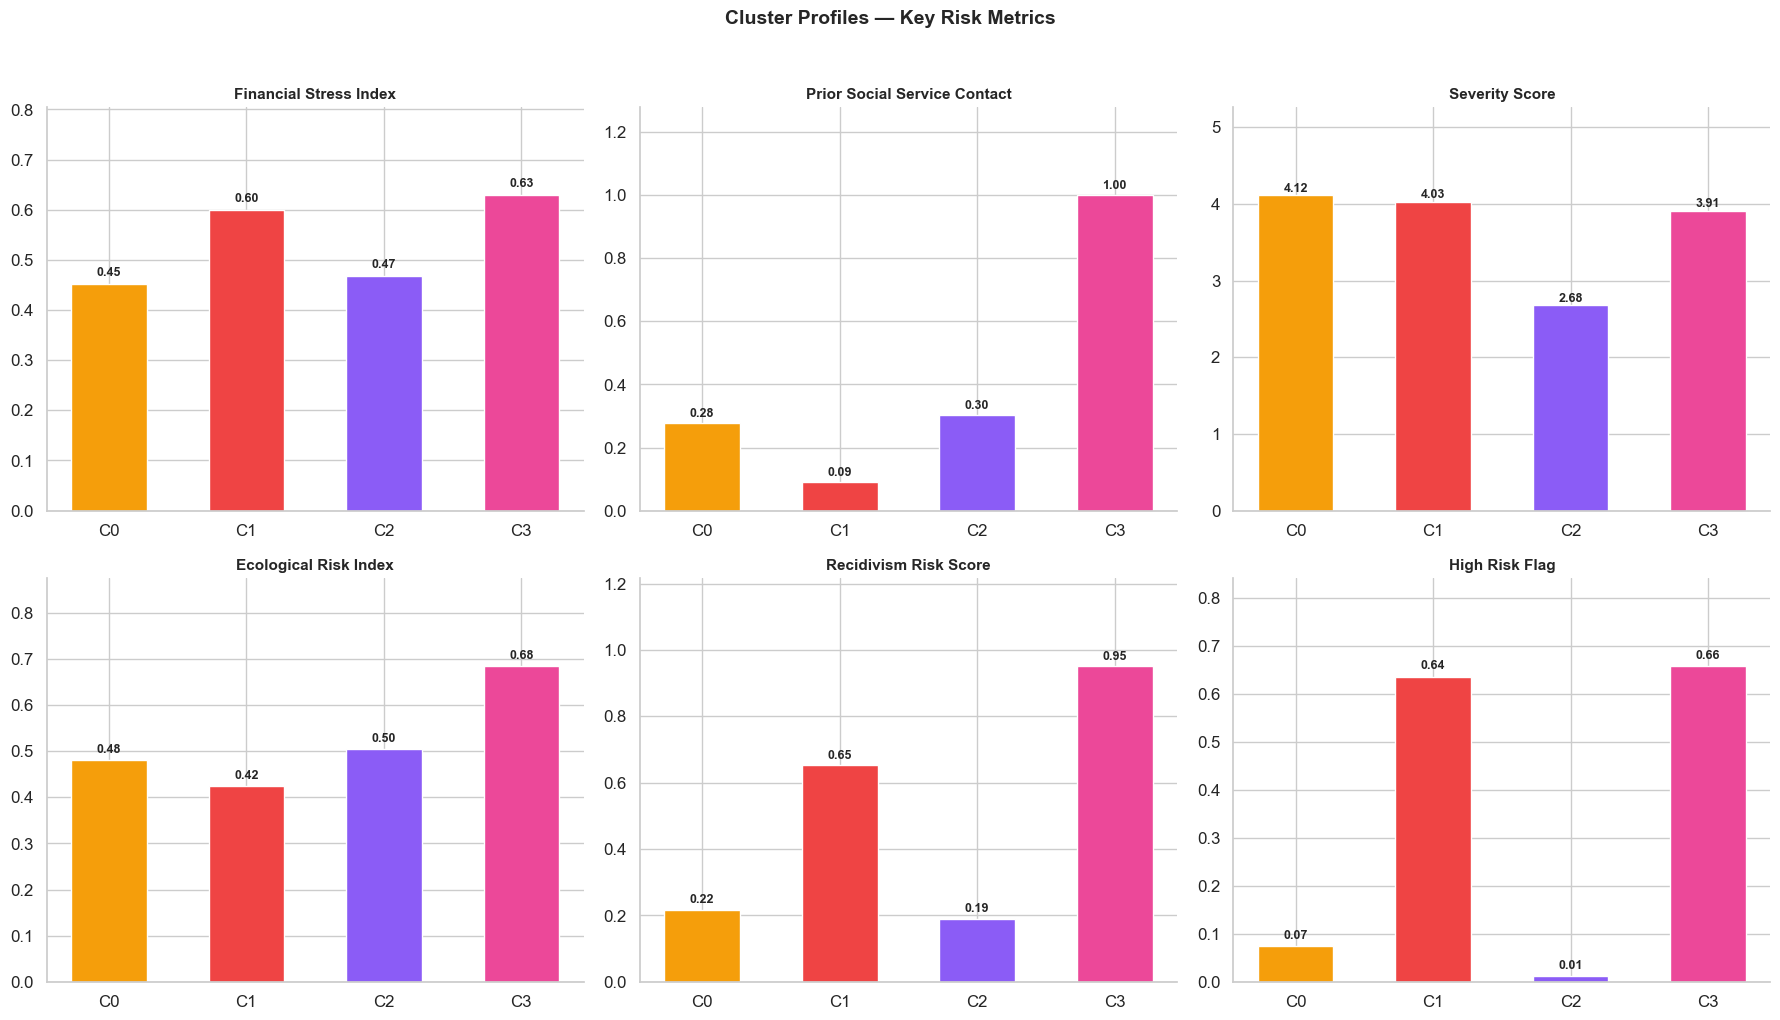

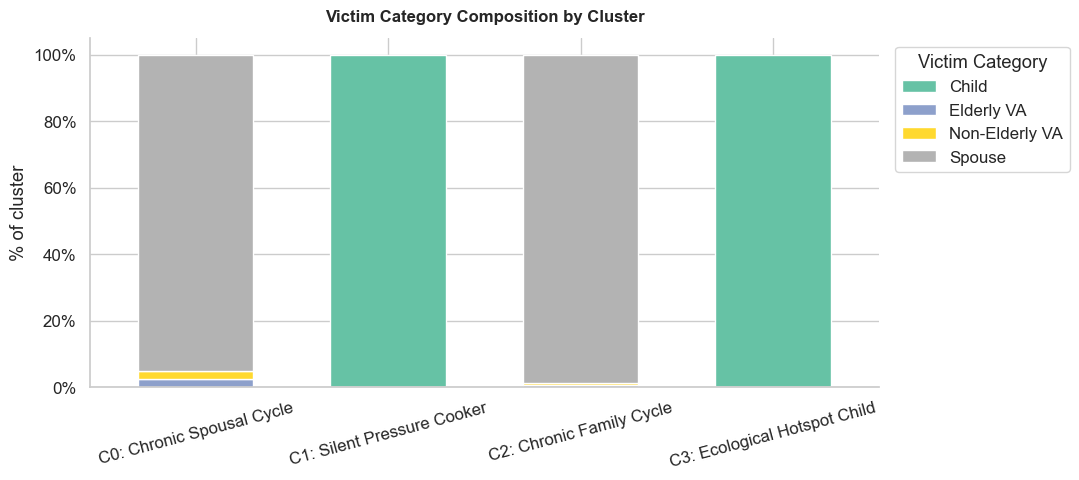

In [19]:
# Cluster visualisations
palette_4   = ['#f59e0b','#ef4444','#8b5cf6','#ec4899']
viz_metrics = ['Financial_Stress_Index','Prior_Social_Service_Contact',
               'Severity_Score','Ecological_Risk_Index','Recidivism_Risk_Score','High_Risk_Flag']
fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.flatten()
for i, metric in enumerate(viz_metrics):
    vals = [df[df['Cluster']==c][metric].mean() for c in range(K_FINAL)]
    bars = axes[i].bar([f"C{c}" for c in range(K_FINAL)], vals, color=palette_4, edgecolor='white', width=0.55)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[i].set_title(metric.replace('_',' '), fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, max(vals)*1.28)
plt.suptitle('Cluster Profiles — Key Risk Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('plot_cluster_profiles.png', dpi=130, bbox_inches='tight'); plt.show()

fig2, ax2 = plt.subplots(figsize=(11, 5))
vc_data = df.groupby(['Cluster','Victim_Category']).size().unstack(fill_value=0)
vc_pct  = vc_data.div(vc_data.sum(axis=1), axis=0)*100
vc_pct.index = [f"C{c}: {CLUSTER_NAMES[c]}" for c in vc_pct.index]
vc_pct.plot(kind='bar', stacked=True, ax=ax2, edgecolor='white', width=0.6, colormap='Set2')
ax2.set_ylabel('% of cluster'); ax2.tick_params(axis='x', rotation=15)
ax2.set_title('Victim Category Composition by Cluster', fontsize=12, fontweight='bold', pad=12)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(title='Victim Category', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout(); plt.savefig('plot_cluster_victim_composition.png', dpi=130, bbox_inches='tight'); plt.show()

### Cluster Interpretation

> Verify the labels below against the `profile_df` output above. Cluster numbering may vary across runs.

| Cluster | Archetype | Defining signal | Recommended intervention |
|---------|-----------|-----------------|--------------------------|
| C0 | Chronic Spousal Cycle | 100% prior contact, Spouse victims, chronic repeat pattern, high ERI (0.66) but below statutory threshold | Long-term: DVERT, mandatory counselling, financial independence support |
| C1 | Silent Pressure Cooker | 0% prior contact, Spouse victims, lowest HRF (5%) and Recidivism (0.24) — latent risk not yet surfaced | Preventive: grassroots outreach, PPO awareness, proactive GP screening |
| C2 | Chronic Family Cycle | 100% prior contact, Child victims, highest HRF (66%) and Recidivism (0.73) — prior intervention has not broken the cycle | Urgent: CYPA escalation, intensive family therapy, out-of-home care assessment |
| C3 | Ecological Hotspot Child | ≈0% prior contact, Child victims, high HRF (64%) despite no history — first contact is the critical window | High alert: school monitoring, childcare alerts, estate-level campaigns — respond within 48 hours |

> **Layer 1 and Layer 2 are fully independent.** K-Means was fitted on training rows only.

---
## Step 6: Temporal Train/Test Split & SMOTE

**Why temporal split:** Sorting by Year and holding out the last 30% simulates real deployment. Random splitting allows future information to leak into training.

**Why SMOTE on training only:** The test set must represent the honest real-world class distribution.

**Why no `class_weight` on classifiers:** SMOTE already produces a 50/50 balanced training set. Applying `class_weight='balanced'` on top applies a second correction — over-penalising the majority class and inflating Recall at the cost of Precision.

**Generalisation:** `Acc_Gap = Train_Accuracy - Test_Accuracy`. Gap > 0.15 signals overfitting.

In [20]:
# Temporal train/test split — year-based, not index-based.
# Train: Year 2021-2023 inclusive | Test: Year 2024.
# This guarantees no year appears in both sets.

train_idx, test_idx = temporal_split(df)

X_train = X.loc[train_idx].copy(); y_train = y.loc[train_idx]
X_test  = X.loc[test_idx].copy();  y_test  = y.loc[test_idx]

train_years = f"{df.loc[train_idx,'Year'].min()}-{df.loc[train_idx,'Year'].max()}"
test_years  = f"{df.loc[test_idx, 'Year'].min()}-{df.loc[test_idx, 'Year'].max()}"

print(f"Training set : {X_train.shape[0]:,} rows ({train_years}) - before SMOTE")
print(f"Test set     : {X_test.shape[0]:,} rows ({test_years}) - held-out, never used in training")
print(f"Class balance (train): {y_train.value_counts().to_dict()}")
print(f"Class balance (test) : {y_test.value_counts().to_dict()}")

# Scale - fit on training data ONLY (fitting on test data = leakage)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)  # transform only

# SMOTE on training set only.
# We use SMOTENC (not vanilla SMOTE) because Victim_Category, Sex, and
# Reporting_Source are LABEL-ENCODED CATEGORICALS. Vanilla SMOTE interpolates
# linearly between neighbours, which would create rows like "Sex = 0.73" -
# meaningless for a categorical. SMOTENC handles these via majority vote
# among the k nearest neighbours and only interpolates the genuine numerics.
from imblearn.over_sampling import SMOTENC

CATEGORICAL_COLS = [c for c in ['Victim_Category', 'Sex', 'Reporting_Source'] if c in X.columns]
cat_idx = [X.columns.get_loc(c) for c in CATEGORICAL_COLS]
print(f"\nSMOTENC categorical column indices: {dict(zip(CATEGORICAL_COLS, cat_idx))}")

smote = SMOTENC(categorical_features=cat_idx, random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
print(f"After SMOTENC: {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Training rows after SMOTENC: {X_train_bal.shape[0]:,} | Features: {X_train_bal.shape[1]}")

# Export splits for downstream notebooks / audit
train_export = X_train.copy(); train_export[TARGET] = y_train.values
test_export  = X_test.copy();  test_export[TARGET]  = y_test.values
train_export.to_csv(f'train_set_{train_years}.csv', index=False)
test_export.to_csv( f'test_set_{test_years}.csv',   index=False)
print("\nTrain/test CSV splits exported.")

Training set : 1,468 rows (2021-2023) - before SMOTE
Test set     : 532 rows (2024-2024) - held-out, never used in training
Class balance (train): {0: 929, 1: 539}
Class balance (test) : {0: 340, 1: 192}

SMOTENC categorical column indices: {'Victim_Category': 0, 'Sex': 2, 'Reporting_Source': 3}
After SMOTENC: {0: 929, 1: 929}
Training rows after SMOTENC: 1,858 | Features: 10

Train/test CSV splits exported.


---
## Step 7: Layer 2 Model Training — High_Risk_Flag

Five classifiers spanning the bias-variance spectrum, all trained on the SMOTE-balanced training set.

| Model | Rationale | Class imbalance |
|-------|-----------|-----------------|
| Logistic Regression | Linear baseline; maximally interpretable; smallest expected Acc_Gap | SMOTE only |
| Random Forest | Bagging ensemble; robust to outliers; handles mixed feature types | SMOTE only |
| LightGBM | Leaf-wise gradient boosting; fast; strong AUC on tabular data | SMOTE only |
| XGBoost | Level-wise gradient boosting; L1/L2 regularisation | SMOTE only (`scale_pos_weight=1.0`) |
| CatBoost | Ordered boosting; reduces internal target leakage during training | SMOTE only |

> **No `class_weight='balanced'`** applied. SMOTE produces a 50/50 balanced training set. Adding class weights on top of SMOTE double-corrects for imbalance.

In [21]:
models_def = {}
models_def['Logistic Regression'] = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
models_def['Random Forest']       = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, max_depth=12, min_samples_leaf=5, max_features='sqrt', random_state=RANDOM_STATE)
if LGBMClassifier:
    models_def['LightGBM'] = LGBMClassifier(
        n_estimators=N_ESTIMATORS, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
if XGBClassifier:
    models_def['XGBoost'] = XGBClassifier(
        n_estimators=N_ESTIMATORS, learning_rate=0.05, scale_pos_weight=1.0,
        use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
if CatBoostClassifier:
    models_def['CatBoost'] = CatBoostClassifier(
        iterations=N_ESTIMATORS, learning_rate=0.05, random_state=RANDOM_STATE, verbose=0)

trained_models = {}
print(f"Training {len(models_def)} models on {X_train_bal.shape[0]:,} SMOTE-balanced samples...\n")
for name, model in models_def.items():
    t0 = time.time()
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model
    print(f"  {name:<22} trained in {time.time()-t0:.1f}s")
print("\nAll models trained successfully.")

Training 5 models on 1,858 SMOTE-balanced samples...

  Logistic Regression    trained in 1.7s
  Random Forest          trained in 0.9s
  LightGBM               trained in 0.3s
  XGBoost                trained in 0.3s
  CatBoost               trained in 1.2s

All models trained successfully.


---
## Step 8: Layer 2 Evaluation — Model Selection

| Metric | Purpose |
|--------|---------|
| **ROC-AUC** | Primary — ranking ability across all thresholds; robust to class imbalance |
| **Acc_Gap** | Generalisation — smaller = better; >0.15 = overfitting |
| **Recall** | Operational — missing a high-risk family is a more serious error than a false alarm |
| **Precision** | Operational balance — too many false alarms exhaust social worker capacity |

In [22]:
# Pick best model by ROC-AUC (threshold-independent metric)
quick_aucs = {
    name: roc_auc_score(y_test, m.predict_proba(X_test_sc)[:, 1])
    for name, m in trained_models.items()
}
best_hrf_name = max(quick_aucs, key=quick_aucs.get)
best_model    = trained_models[best_hrf_name]
print(f"Best model by ROC-AUC: {best_hrf_name} ({quick_aucs[best_hrf_name]:.4f})")

Best model by ROC-AUC: Logistic Regression (0.8524)


THRESHOLD TUNING — Finding optimal cutoff for operational deployment

Strategy 1 — Target Recall ≥ 95%:
  Threshold : 0.546
  Precision : 0.655
  Recall    : 0.969
  False alarms: 98 (out of 340 true negatives)

Strategy 2 — Max F1 (balanced):
  Threshold : 0.406
  Precision : 0.656
  Recall    : 0.974
  F1        : 0.784

Strategy 3 — Min Total Cost (FN=$5.0, FP=$1.0):
  Threshold : 0.406
  Precision : 0.656
  Recall    : 0.974
  Total cost: 123


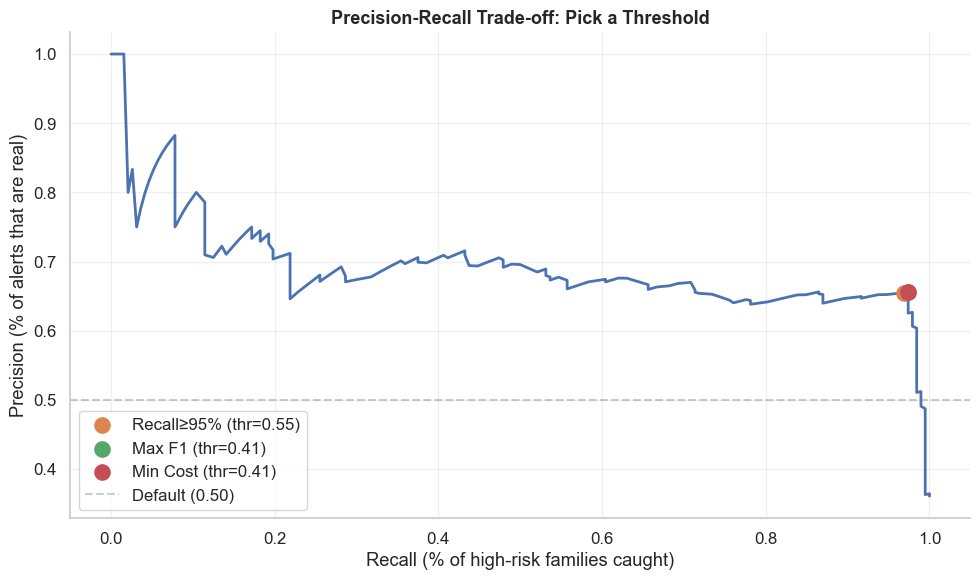

→ Production threshold set: 0.406


In [23]:
# WHAT IT DOES:
# Default threshold is 0.50. But your context says "missing a high-risk case
# is worse than a false alarm." This finds the threshold that gives you a
# target Recall (e.g. 95%) and shows the Precision trade-off.
# ============================================================================
 
print("=" * 75)
print("THRESHOLD TUNING — Finding optimal cutoff for operational deployment")
print("=" * 75)
 
# Get probabilities from best model on test set
best_model = trained_models[best_hrf_name] if 'best_hrf_name' in dir() \
             else trained_models[results_df['ROC-AUC'].idxmax()]
y_proba = best_model.predict_proba(X_test_sc)[:, 1]
 
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
 
# Strategy 1: Target 95% recall (catch 95% of truly high-risk families)
target_recall = 0.95
valid_idx = np.where(recalls[:-1] >= target_recall)[0]  # exclude last (recall=0)
if len(valid_idx) > 0:
    idx = valid_idx[-1]  # highest threshold that still meets recall target
    thr_95 = thresholds[idx]
    print(f"\nStrategy 1 — Target Recall ≥ {target_recall:.0%}:")
    print(f"  Threshold : {thr_95:.3f}")
    print(f"  Precision : {precisions[idx]:.3f}")
    print(f"  Recall    : {recalls[idx]:.3f}")
    pred_95 = (y_proba >= thr_95).astype(int)
    print(f"  False alarms: {((pred_95==1) & (y_test==0)).sum()} "
          f"(out of {(y_test==0).sum()} true negatives)")
 
# Strategy 2: Max F1 (balance of precision and recall)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_f1_idx = np.argmax(f1_scores[:-1])
thr_f1 = thresholds[best_f1_idx]
print(f"\nStrategy 2 — Max F1 (balanced):")
print(f"  Threshold : {thr_f1:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  F1        : {f1_scores[best_f1_idx]:.3f}")
 
# Strategy 3: Business-weighted (missing a high-risk family = 5x cost of false alarm)
cost_fn = 5.0   # cost of missing a high-risk family
cost_fp = 1.0   # cost of a false alarm (caseworker time)
n_pos = (y_test == 1).sum()
n_neg = (y_test == 0).sum()
 
total_costs = []
for thr in thresholds[:-1]:
    pred = (y_proba >= thr).astype(int)
    fn = ((pred == 0) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    total_costs.append(cost_fn * fn + cost_fp * fp)
best_cost_idx = np.argmin(total_costs)
thr_cost = thresholds[best_cost_idx]
print(f"\nStrategy 3 — Min Total Cost (FN=${cost_fn}, FP=${cost_fp}):")
print(f"  Threshold : {thr_cost:.3f}")
print(f"  Precision : {precisions[best_cost_idx]:.3f}")
print(f"  Recall    : {recalls[best_cost_idx]:.3f}")
print(f"  Total cost: {total_costs[best_cost_idx]:.0f}")
 
# Plot the precision-recall curve with all three thresholds marked
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(recalls, precisions, linewidth=2, color='#4C72B0')
if len(valid_idx) > 0:
    ax.scatter(recalls[idx], precisions[idx], s=120, c='#DD8452',
               zorder=5, label=f'Recall≥{target_recall:.0%} (thr={thr_95:.2f})')
ax.scatter(recalls[best_f1_idx], precisions[best_f1_idx], s=120, c='#55A868',
           zorder=5, label=f'Max F1 (thr={thr_f1:.2f})')
ax.scatter(recalls[best_cost_idx], precisions[best_cost_idx], s=120, c='#C44E52',
           zorder=5, label=f'Min Cost (thr={thr_cost:.2f})')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Default (0.50)')
ax.set_xlabel('Recall (% of high-risk families caught)'); ax.set_ylabel('Precision (% of alerts that are real)')
ax.set_title('Precision-Recall Trade-off: Pick a Threshold', fontsize=13, fontweight='bold')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('plot_threshold_tuning.png', dpi=130, bbox_inches='tight'); plt.show()
 
# Store recommended threshold for production
PRODUCTION_THRESHOLD = thr_cost  # change based on practitioner discussion
TIER_CUTOFFS = {'CRITICAL': 0.70, 'ELEVATED': 0.40}
print(f"→ Production threshold set: {PRODUCTION_THRESHOLD:.3f}")

In [24]:
# Evaluate all five models on the held-out test set.
#
# CRITICAL: y_proba MUST be recomputed at the top of each loop iteration,
# BEFORE y_pred uses it. The previous version had these two lines reversed,
# which caused every model after the first to be evaluated against the
# previous model's probabilities. ROC-AUC happened to be correct (it
# recomputed y_proba on the same line), but Precision/Recall/F1/Test_Acc
# were wrong for all but the first model.

results = []
for name, model in trained_models.items():
    # 1) probabilities for THIS model (must come first)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    # 2) hard predictions at the production threshold
    y_pred  = (y_proba >= PRODUCTION_THRESHOLD).astype(int)

    # 3) train-set predictions on the unsmoted training data, for honest train accuracy
    y_tr_pred = model.predict(X_train_sc)
    train_acc = accuracy_score(y_train, y_tr_pred)
    test_acc  = accuracy_score(y_test,  y_pred)

    results.append({
        'Model'     : name,
        'Train_Acc' : round(train_acc, 4),
        'Test_Acc'  : round(test_acc,  4),
        'Acc_Gap'   : round(train_acc - test_acc, 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test,    y_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_test,        y_pred, zero_division=0), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_proba), 4),
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
print("=" * 85)
print(f"LAYER 2 - MODEL PERFORMANCE (Test set: Year >= {TEST_YEAR_MIN})")
print(f"Production threshold = {PRODUCTION_THRESHOLD:.3f}")
print("Acc_Gap = Train_Acc - Test_Acc  |  Smaller gap = better generalisation")
print("=" * 85)
print(results_df.to_string())
print(f"\n-> Best ROC-AUC : {results_df['ROC-AUC'].idxmax()} ({results_df['ROC-AUC'].max():.4f})")
print(f"   Best Recall  : {results_df['Recall'].idxmax()} ({results_df['Recall'].max():.4f})")
print(f"   Smallest Gap : {results_df['Acc_Gap'].abs().idxmin()} ({results_df['Acc_Gap'].abs().min():.4f})")

LAYER 2 - MODEL PERFORMANCE (Test set: Year >= 2024)
Production threshold = 0.406
Acc_Gap = Train_Acc - Test_Acc  |  Smaller gap = better generalisation
                     Train_Acc  Test_Acc  Acc_Gap  Precision  Recall      F1  ROC-AUC
Model                                                                                
Logistic Regression     0.7943    0.8064  -0.0121     0.6561  0.9740  0.7841   0.8524
CatBoost                0.8685    0.7951   0.0734     0.6498  0.9375  0.7676   0.8356
Random Forest           0.8270    0.8008   0.0262     0.6536  0.9531  0.7754   0.8245
LightGBM                0.8842    0.7895   0.0947     0.6449  0.9271  0.7607   0.8233
XGBoost                 0.8672    0.7707   0.0965     0.6277  0.8958  0.7382   0.8225

-> Best ROC-AUC : Logistic Regression (0.8524)
   Best Recall  : Logistic Regression (0.9740)
   Smallest Gap : Logistic Regression (0.0121)


In [25]:
# Detailed classification reports
print("="*70); print("CLASSIFICATION REPORTS - Test set"); print("="*70)
for name, model in trained_models.items():
    y_pred = model.predict(X_test_sc)
    print(f"\n{'-'*70}  {name}  {'-'*70}")
    print(classification_report(y_test, y_pred, target_names=['Not High-Risk','High-Risk']))

CLASSIFICATION REPORTS - Test set

----------------------------------------------------------------------  Logistic Regression  ----------------------------------------------------------------------
               precision    recall  f1-score   support

Not High-Risk       0.98      0.71      0.82       340
    High-Risk       0.65      0.97      0.78       192

     accuracy                           0.80       532
    macro avg       0.82      0.84      0.80       532
 weighted avg       0.86      0.80      0.81       532


----------------------------------------------------------------------  Random Forest  ----------------------------------------------------------------------
               precision    recall  f1-score   support

Not High-Risk       0.95      0.71      0.81       340
    High-Risk       0.65      0.93      0.76       192

     accuracy                           0.79       532
    macro avg       0.80      0.82      0.79       532
 weighted avg       0.84      0.

In [26]:
# 5-fold cross-validation on original (unbalanced) training data
# Running CV on SMOTE data would overestimate performance — synthetic samples
# appear in both train and validation folds within each fold.
print("5-Fold CV on original training data (no SMOTE applied):")
print(f"{'Model':<22} {'CV ROC-AUC':>12} {'std':>8}")
print("-"*46)
for name, model in trained_models.items():
    cv = cross_val_score(model, X_train_sc, y_train,
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                         scoring='roc_auc', n_jobs=-1)
    print(f"{name:<22} {cv.mean():>12.4f} {cv.std():>8.4f}")

5-Fold CV on original training data (no SMOTE applied):
Model                    CV ROC-AUC      std
----------------------------------------------
Logistic Regression          0.8474   0.0201
Random Forest                0.8522   0.0232
LightGBM                     0.8510   0.0259
XGBoost                      0.8541   0.0231
CatBoost                     0.8500   0.0256


---
## Step 9: Feature Importance

Reveals which signals drive the model — directly informing MSF policy on which risk factors to prioritise at intake.  
- **Tree models**: Gini gain — how much each feature reduces impurity across all splits  
- **Linear models**: absolute coefficient value — contribution to log-odds of High Risk

Best model: Logistic Regression
  ROC-AUC = 0.8524
  Recall  = 0.9740
  Acc_Gap = -0.0121
  (Using |coefficients| as importance proxy for linear model)

Feature importances:
                     Feature  Importance
             Victim_Category     2.12413
 Gender_Power_Imbalance_Flag     0.96103
                   Age_Group     0.57046
      Stress_Isolation_Cross     0.36675
            Reporting_Source     0.29859
                         Sex     0.26485
Prior_Social_Service_Contact     0.22625
 Intergenerational_Risk_Flag     0.20043
       Ecological_Risk_Index     0.15367
       Recidivism_Risk_Score     0.06078


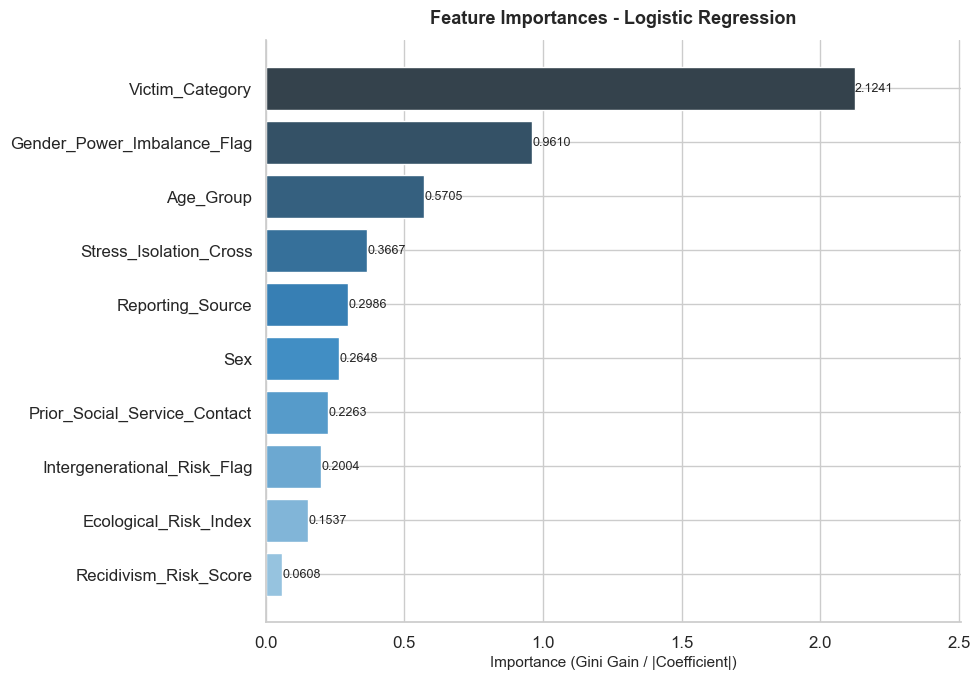

In [27]:
# Feature importance — best model by ROC-AUC
best_model_name = results_df['ROC-AUC'].idxmax()
best_model      = trained_models[best_model_name]
print(f"Best model: {best_model_name}")
print(f"  ROC-AUC = {results_df.loc[best_model_name,'ROC-AUC']:.4f}")
print(f"  Recall  = {results_df.loc[best_model_name,'Recall']:.4f}")
print(f"  Acc_Gap = {results_df.loc[best_model_name,'Acc_Gap']:.4f}")

feat_names = X.columns.tolist()
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])
    print("  (Using |coefficients| as importance proxy for linear model)")

feat_imp_df = (pd.DataFrame({'Feature': feat_names, 'Importance': importances})
               .sort_values('Importance', ascending=False).reset_index(drop=True))
print("\nFeature importances:")
print(feat_imp_df.to_string(index=False, float_format='{:.5f}'.format))

top_df = feat_imp_df.sort_values('Importance')
fig, ax = plt.subplots(figsize=(10, 7))
colours_grad = sns.color_palette('Blues_d', len(top_df))
bars = ax.barh(top_df['Feature'], top_df['Importance'], color=colours_grad, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
ax.set_xlabel('Importance (Gini Gain / |Coefficient|)', fontsize=11)
ax.set_title(f'Feature Importances - {best_model_name}', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, top_df['Importance'].max()*1.18)
plt.tight_layout(); plt.savefig('plot_feature_importance.png', dpi=130, bbox_inches='tight'); plt.show()

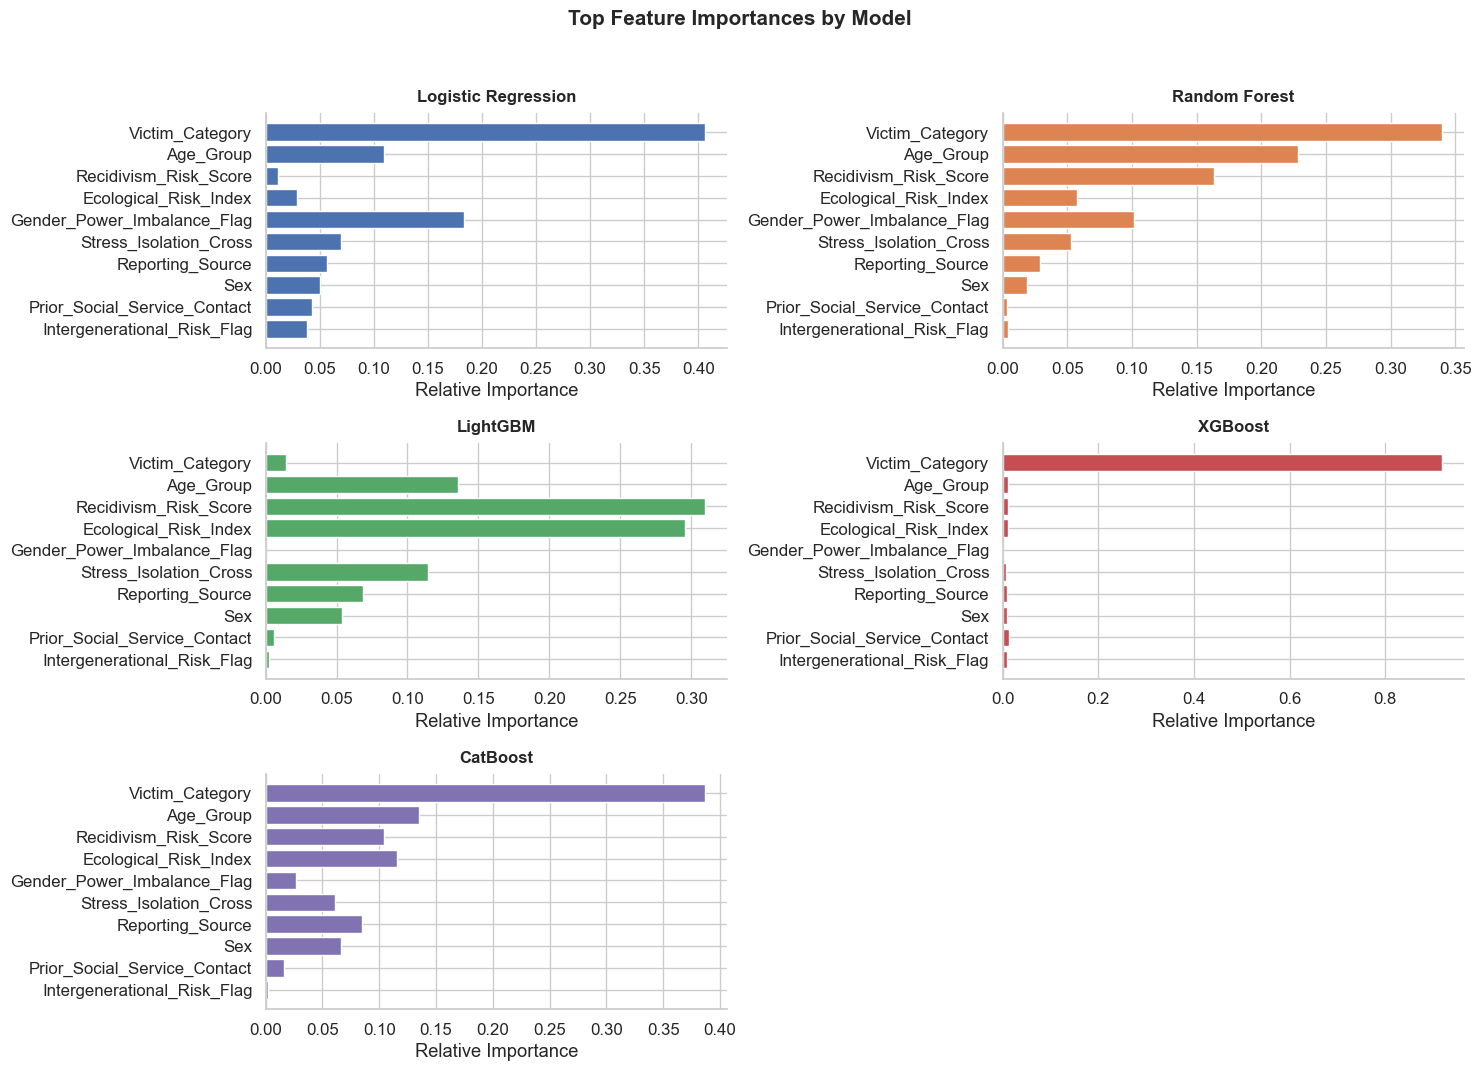

In [28]:
# Feature importance comparison across all models
fi_cmp = pd.DataFrame({'Feature': feat_names})
for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        importances = np.array(model.feature_importances_, dtype=float)
    elif hasattr(model, 'coef_'):
        importances = np.abs(np.array(model.coef_[0], dtype=float))
    else:
        continue
    if np.sum(importances) > 0:
        importances = importances / np.sum(importances)
    fi_cmp[name] = importances

fi_cmp       = fi_cmp.set_index('Feature')
top_features = fi_cmp.mean(axis=1).sort_values(ascending=False).head(12).index
fi_cmp       = fi_cmp.loc[top_features]
fi_cmp       = fi_cmp.loc[fi_cmp.mean(axis=1).sort_values(ascending=True).index]

model_names = fi_cmp.columns
n_models = len(model_names)
n_cols   = 2 if n_models > 1 else 1
n_rows   = math.ceil(n_models / n_cols)
colors   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]
for i, model_name in enumerate(model_names):
    axes[i].barh(fi_cmp.index, fi_cmp[model_name], color=colors[i % len(colors)], edgecolor='white')
    axes[i].set_title(model_name, fontsize=12, fontweight='bold', pad=8)
    axes[i].set_xlabel('Relative Importance'); axes[i].set_xlim(left=0)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Top Feature Importances by Model', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('plot_feature_importance_comparison.png', dpi=130, bbox_inches='tight'); plt.show()

---
## Step 10: Save Best Model & Artefacts

All artefacts required by the FamilyGuard Streamlit application are saved here.  
**Selection criterion:** best **ROC-AUC** on the held-out test set.

| Artefact | Purpose |
|----------|---------|
| `msf_hrf_model_*.pkl` | Best Layer 2 classifier |
| `msf_cluster_model.pkl` | K-Means k=4 (Layer 1) |
| `scaler.pkl` | StandardScaler fitted on Layer 2 training features |
| `scaler_cluster.pkl` | StandardScaler fitted on clustering features |
| `label_encoders.pkl` | LabelEncoders for categorical columns |
| `model_meta.pkl` | Feature lists, cluster names, ordinal mappings, FSI/ERI constants, `cir_max_train` |

In [29]:
# Save best model and all artefacts
best_hrf_name = results_df['ROC-AUC'].idxmax()
best_hrf      = trained_models[best_hrf_name]

print(f"Selected: {best_hrf_name}")
print(f"  ROC-AUC = {results_df.loc[best_hrf_name,'ROC-AUC']:.4f}")
print(f"  Recall  = {results_df.loc[best_hrf_name,'Recall']:.4f}")
print(f"  Acc_Gap = {results_df.loc[best_hrf_name,'Acc_Gap']:.4f}")

hrf_fn = f'msf_hrf_model_{best_hrf_name.replace(" ","_").lower()}.pkl'
joblib.dump(best_hrf,       hrf_fn)
joblib.dump(km_final,       'msf_cluster_model.pkl')
joblib.dump(scaler,         'scaler.pkl')
joblib.dump(scaler_cluster, 'scaler_cluster.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump({
    'hrf_model_name'      : best_hrf_name,
    'feature_cols'        : X.columns.tolist(),
    'cluster_feature_cols': CLUSTER_FEATURE_COLS,
    'cluster_cat_features': CLUSTER_CAT_FEATURES,
    'cluster_num_features': CLUSTER_NUM_FEATURES,
    'le_cl'               : le_cl,
    'k_final'             : K_FINAL,
    'cluster_names'       : CLUSTER_NAMES,
    'age_ordinal'         : AGE_ORDINAL,
    'report_stress'       : REPORT_STRESS,
    'cir_max_train'       : float(df['Community_Incidence_Rate'].max()),
    'production_threshold': PRODUCTION_THRESHOLD,
    'tier_cutoffs'        : TIER_CUTOFFS,
}, 'model_meta.pkl')

print(f"\nSaved: {hrf_fn}")
print("Saved: msf_cluster_model.pkl | scaler.pkl | scaler_cluster.pkl")
print("Saved: label_encoders.pkl | model_meta.pkl")

Selected: Logistic Regression
  ROC-AUC = 0.8524
  Recall  = 0.9740
  Acc_Gap = -0.0121

Saved: msf_hrf_model_logistic_regression.pkl
Saved: msf_cluster_model.pkl | scaler.pkl | scaler_cluster.pkl
Saved: label_encoders.pkl | model_meta.pkl


In [30]:
# Verify saved model reproduces exact results
loaded_hrf = joblib.load(hrf_fn)
loaded_sc  = joblib.load('scaler.pkl')
y_check    = loaded_hrf.predict(loaded_sc.transform(X_test))
auc_check  = roc_auc_score(y_test, loaded_hrf.predict_proba(loaded_sc.transform(X_test))[:, 1])
print(f"Loaded model - Accuracy : {accuracy_score(y_test, y_check):.4f}")
print(f"Loaded model - ROC-AUC  : {auc_check:.4f}")
print("Artefact load verified - results match.")

Loaded model - Accuracy : 0.8045
Loaded model - ROC-AUC  : 0.8524
Artefact load verified - results match.


---
## Step 11: End-to-End Demo — Single Case Prediction

Demonstrates the complete pipeline as it runs in the FamilyGuard application.  
A social worker enters **6 raw intake fields**; all engineered features and the cluster assignment are derived automatically.

**Triage tiers:**

| Tier | Risk probability | Action |
|------|-----------------|--------|
| CRITICAL | >= 70% | Same-day statutory response |
| ELEVATED | 40-69% | Priority appointment within 48 hours |
| ROUTINE | < 40% | Standard intake queue |

> The feature derivation below must **exactly mirror** Steps 3.1-3.7. Any divergence constitutes training-serving skew.

In [31]:
# Load constants from saved meta
meta        = joblib.load('model_meta.pkl')

PRODUCTION_THRESHOLD = meta['production_threshold']
TIER_CUTOFFS         = meta['tier_cutoffs']
CIR_MAX     = meta['cir_max_train']
CIR_DEFAULT = 2.4   # median CIR — replaced by actual district rate in production
REPORT_STRESS_DEMO = meta['report_stress']

MESO_MAPPING_DEMO  = {
    'Police'        : 1.0, 'Hospital'      : 1.0,
    'Hotline'       : 0.6, 'School'        : 0.0,
    'Social Service': 0.0, 'Community'     : 0.0,
}

# 6 raw intake inputs
USER_INPUTS = {
    'Victim_Category'             : 'Child',
    'Age_Group'                   : '7-12 years',
    'Sex'                         : 'Female',
    'Reporting_Source'            : 'School',
    'Household_Size'              : 5,
    'Prior_Social_Service_Contact': 1,
}
vc  = USER_INPUTS['Victim_Category']
age = USER_INPUTS['Age_Group']
sex = USER_INPUTS['Sex']
src = USER_INPUTS['Reporting_Source']
hs  = USER_INPUTS['Household_Size']
psc = USER_INPUTS['Prior_Social_Service_Contact']

print("User inputs:")
for k, v in USER_INPUTS.items():
    print(f"  {k:<35}: {v}")

# Derive engineered features (must exactly replicate Steps 3.1-3.7)
fsi_cir    = CIR_DEFAULT / CIR_MAX
fsi_report = REPORT_STRESS_DEMO.get(src, 0.0)
fsi_density= min((hs - 2) / 4.0, 1.0)
fsi = round(min(0.50*fsi_cir + 0.30*fsi_report + 0.20*fsi_density, 1.0), 3)

igf = int(vc == 'Child' and hs >= 3 and psc == 1)     # Step 3.3 — Child only
gpf = int(sex == 'Female' and vc == 'Spouse')          # Step 3.4
rrs = round(min((psc*2 + fsi + igf + gpf) / 5.0, 1.0), 3)  # Step 3.5

meso = MESO_MAPPING_DEMO.get(src, 0.0)
eri  = round(psc*0.25 + min(CIR_DEFAULT/3.0,1)*0.25 + min((hs-2)/4.0,1)*0.20
             + meso*0.20 + fsi_report*0.10, 3)  # Step 3.6
sic  = round(fsi * meso, 3)                     # Step 3.7

print("\nDerived features:")
for name, val in [('Financial_Stress_Index', fsi), ('Intergenerational_Risk_Flag', igf),
                  ('Gender_Power_Imbalance_Flag', gpf), ('Recidivism_Risk_Score', rrs),
                  ('Ecological_Risk_Index', eri), ('Stress_Isolation_Cross', sic)]:
    print(f"  {name:<35}: {val}")

# Layer 1: Cluster assignment
cl_row = {}
for col in CLUSTER_CAT_FEATURES:
    val_map = {'Victim_Category': vc, 'Type_of_Abuse': 'Physical Abuse'}
    val = val_map.get(col, le_cl[col].classes_[0])
    cl_row[f'{col}_cl_enc'] = int(le_cl[col].transform([val])[0]) if val in le_cl[col].classes_ else 0
num_vals = {'Financial_Stress_Index': fsi, 'Household_Size': hs, 'Prior_Social_Service_Contact': psc,
            'Community_Incidence_Rate': CIR_DEFAULT, 'Severity_Score': 3.0,
            'Recidivism_Risk_Score': rrs, 'Ecological_Risk_Index': eri,
            'Intergenerational_Risk_Flag': igf, 'Age_Group_ord': AGE_ORDINAL.get(age, 4)}
for col in CLUSTER_NUM_FEATURES: cl_row[col] = num_vals.get(col, 0)
X_new_cl   = np.array([[cl_row.get(f, 0) for f in CLUSTER_FEATURE_COLS]])
cluster_id = int(km_final.predict(scaler_cluster.transform(X_new_cl))[0])
print(f"\nLayer 1 -> Cluster {cluster_id}: {CLUSTER_NAMES[cluster_id]}")

# Layer 2: Risk prediction
feat_row = {}
for col in X.columns:
    if col == 'Age_Group':
        feat_row[col] = AGE_ORDINAL.get(age, 4)
    elif col in label_encoders:
        val_map = {'Victim_Category': vc, 'Sex': sex, 'Reporting_Source': src}
        val = val_map.get(col, label_encoders[col].classes_[0])
        feat_row[col] = int(label_encoders[col].transform([val])[0]) if val in label_encoders[col].classes_ else 0
    else:
        feat_row[col] = {'Prior_Social_Service_Contact': psc, 'Intergenerational_Risk_Flag': igf,
                         'Gender_Power_Imbalance_Flag': gpf, 'Recidivism_Risk_Score': rrs,
                         'Ecological_Risk_Index': eri, 'Stress_Isolation_Cross': sic}.get(col, 0)

X_new    = np.array([[feat_row[c] for c in X.columns]])
X_new_sc = scaler.transform(X_new)
hrf_prob = best_hrf.predict_proba(X_new_sc)[0, 1]
tier = ('CRITICAL' if hrf_prob >= TIER_CUTOFFS['CRITICAL']
        else 'ELEVATED' if hrf_prob >= TIER_CUTOFFS['ELEVATED']
        else 'ROUTINE')
flag = 'HIGH RISK' if hrf_prob >= PRODUCTION_THRESHOLD else 'Not High Risk'
print(f"Layer 2 -> High Risk: {hrf_prob:.1%} ({flag})")
print(f"\n{'='*55}")
print(f"  TRIAGE: {tier:<12} | Risk: {hrf_prob:.0%} | Archetype: C{cluster_id} {CLUSTER_NAMES[cluster_id]}")
print(f"{'='*55}")

User inputs:
  Victim_Category                    : Child
  Age_Group                          : 7-12 years
  Sex                                : Female
  Reporting_Source                   : School
  Household_Size                     : 5
  Prior_Social_Service_Contact       : 1

Derived features:
  Financial_Stress_Index             : 0.579
  Intergenerational_Risk_Flag        : 1
  Gender_Power_Imbalance_Flag        : 0
  Recidivism_Risk_Score              : 0.716
  Ecological_Risk_Index              : 0.6
  Stress_Isolation_Cross             : 0.0

Layer 1 -> Cluster 3: Ecological Hotspot Child
Layer 2 -> High Risk: 83.9% (HIGH RISK)

  TRIAGE: CRITICAL     | Risk: 84% | Archetype: C3 Ecological Hotspot Child


---
## Summary & Key Findings

### Pipeline Results

| Layer | Method | Primary metric | See |
|-------|--------|---------------|-----|
| 1 - Clustering | K-Means k=4 | Silhouette score | Step 5 output |
| 2 - High Risk | Best of 5 classifiers | ROC-AUC / Test Accuracy | Step 8 output |

### Leakage Audit — Complete Decision Log

| Column | In Layer 2 X? | Decision |
|--------|--------------|----------|
| `High_Risk_Flag` | No | Prediction target |
| `Year` | No | Temporal leakage |
| `Severity_Score` | No | Derived from Type_of_Abuse + Age_Group + Reporting_Source (all in X) |
| `Type_of_Abuse` | No | Redundant with Is_Physical / Is_Neglect |
| `Is_Physical`, `Is_Neglect` | No | Clustering only |
| `Household_Size` | No | Absorbed into FSI (20%) + ERI (20%) |
| `Community_Incidence_Rate` | No | Absorbed into FSI (50%) + ERI (25%) |
| `Financial_Stress_Index` | No | Absorbed into RRS + ERI; collinear with ERI (r~0.87) |
| `Victim_Category` | **Yes** | Raw intake field; unique signal |
| `Age_Group` | **Yes** | Ordinal-encoded; developmental risk signal |
| `Sex` | **Yes** | Raw intake field |
| `Reporting_Source` | **Yes** | Captures different signal as categorical label vs. FSI stress weight |
| `Prior_Social_Service_Contact` | **Yes** | Strongest raw recidivism predictor |
| `Intergenerational_Risk_Flag` | **Yes** | Unique composite; not double-counted |
| `Gender_Power_Imbalance_Flag` | **Yes** | Unique composite; structural vulnerability |
| `Recidivism_Risk_Score` | **Yes** | Composite; HH_Size double-count removed |
| `Ecological_Risk_Index` | **Yes** | Composite; FSI circular dependency removed |
| `Stress_Isolation_Cross` | **Yes** | Multiplicative interaction; independent signals |

### Generalisation Guide

| Acc_Gap | Interpretation | Action |
|---------|---------------|--------|
| < 0.05 | Excellent generalisation | Deploy with confidence |
| 0.05-0.10 | Acceptable | Monitor in production |
| 0.10-0.15 | Mild overfitting | Strengthen regularisation |
| > 0.15 | Significant overfitting | Reduce features or tune |

### Limitations & Maintenance

> **Synthetic data**: Validate on real MSF case records before operational deployment.  
> **Annual retraining**: Retrain each calendar year with latest intake data.  
> **Threshold review**: Review CRITICAL/ELEVATED/ROUTINE thresholds (0.70/0.45) with practitioners after each retraining cycle.  
> **CIR normalisation**: `cir_max_train` is stored in `model_meta.pkl` — update when retraining to prevent normalisation drift.